# Credit Scoring MLOps

## Analyse exploratoire des données

L'objectif de cette analyse exploratoire est de :
- comprendre la structure et le contenu des jeux de données fournis ;
- identifier les variables clés, les valeurs manquantes et les distributions ;
- détecter les anomalies et les valeurs aberrantes ;
- explorer les corrélations entre les features et la variable cible (TARGET) ;
- préparer les décisions de prétraitement pour le notebook suivant.

### Contexte métier

La société financière **"Prêt à dépenser"** vise à prédire la probabilité de défaut de remboursement d'un client.
La variable cible `TARGET` vaut :
- `0` — crédit accordé
- `1` — crédit refusé

Les données proviennent du challenge Kaggle **Home Credit Default Risk** et comprennent plusieurs tables liées par la clé `SK_ID_CURR`.


## 0. Setup & imports

In [ ]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import src.utils as utils
import src.visualizer as vi
import missingno as msno

# Configuration de l'affichage
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 60)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

# Chemins des données
DATA_RAW = "../data/raw/"
TARGET = 'TARGET'
PALETTE_TARGET = {0: '#2ecc71', 1: '#e74c3c'}  # vert = bon client, rouge = mauvais


---
## 1. `application_train.csv` & `application_test.csv` — Table principale

### 1.1 Chargement & aperçu complet
- Chargement des deux tables
- `explore_dataframe()` → shape, info, describe, NaN, types de variables, doublons

In [2]:
# Chargement des tables principales
app_train = pd.read_csv(DATA_RAW + "application_train.csv")
app_test  = pd.read_csv(DATA_RAW + "application_test.csv")

In [3]:
utils.explore_dataframe(app_train)

📋 INFORMATIONS GÉNÉRALES
• Lignes    : 307511
• Colonnes : 122

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB

--- DESCRIBE ---


,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,...,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,...,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,...,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.977752,0.755746,0.044595,0.078078,0.149213,0.225897,0.231625,0.067169,0.101954,0.108607,0.008651,0.028236,0.102547,1.422245,0.143421,1.405292,0.100049,-962.858788,0.000042,0.710023,0.000081,0.015115,0.088055,0.000192


--- MISSING VALUES ---

🌐 Pourcentage de cellules vides sur tout le DataFrame : 24.40%

📊 Nombre de colonne avec des cellules vides : 67


,Colonne,Valeurs manquantes,Pourcentage (%)
48,COMMONAREA_AVG,214865,69.87
62,COMMONAREA_MODE,214865,69.87
76,COMMONAREA_MEDI,214865,69.87
84,NONLIVINGAPARTMENTS_MEDI,213514,69.43
70,NONLIVINGAPARTMENTS_MODE,213514,69.43



=== CLASSIFICATION DES VARIABLES ===
QUANTITATIVE (64): ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE', 'CNT_FAM_MEMBERS', 'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_REGISTRATION', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'HOUR_APPR_PROCESS_START', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'NO

In [4]:
utils.explore_dataframe(app_test)

📋 INFORMATIONS GÉNÉRALES
• Lignes    : 48744
• Colonnes : 121

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), str(16)
memory usage: 45.0 MB

--- DESCRIBE ---


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,...,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,48744.000000,48744.000000,4.874400e+04,4.874400e+04,48720.000000,4.874400e+04,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,16432.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,28212.000000,48736.000000,40076.000000,24857.000000,21103.000000,25888.000000,16926.000000,15249.000000,23555.000000,25165.000000,25423.000000,16278.000000,20490.000000,15964.000000,25192.000000,15397.000000,22660.000000,24857.000000,21103.000000,25888.000000,16926.000000,15249.000000,...,15964.000000,25192.000000,15397.000000,22660.000000,24857.000000,21103.000000,25888.000000,16926.000000,15249.000000,23555.000000,25165.000000,25423.000000,16278.000000,20490.000000,15964.000000,25192.000000,15397.000000,22660.000000,26120.000000,48715.000000,48715.000000,48715.000000,48715.000000,48744.000000,48744.0,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.000000,48744.0,48744.000000,48744.0,48744.0,48744.0,48744.0,48744.0,48744.0,48744.000000,48744.0,48744.0,48744.0,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000,42695.000000
mean,277796.676350,0.397054,1.784318e+05,5.167404e+05,29426.240209,4.626188e+05,0.021226,-16068.084605,67485.366322,-4967.652716,-3051.712949,11.786027,0.999979,0.809720,0.204702,0.998400,0.263130,0.162646,2.146767,2.038159,2.012596,12.007365,0.018833,0.055166,0.042036,0.077466,0.224664,0.174216,0.501180,0.518021,0.500106,0.122388,0.090065,0.978828,0.751137,0.047624,0.085168,0.151777,0.233706,0.238423,0.067192,0.105885,0.112286,0.009231,0.029387,0.119078,0.088998,0.978292,0.758327,0.045223,...,0.110874,0.110687,0.008358,0.028161,0.122809,0.089529,0.978822,0.754344,0.047420,0.084128,0.151200,0.233154,0.237846,0.068069,0.107063,0.113368,0.008979,0.029296,0.107129,1.447644,0.143652,1.435738,0.101139,-1077.766228,0.0,0.786620,0.000103,0.014751,0.087477,0.000041,0.088462,0.004493,0.0,0.001169,0.0,0.0,0.0,0.0,0.0,0.0,0.001559,0.0,0.0,0.0,0.002108,0.001803,0.002787,0.009299,0.546902,1.983769
std,10


--- MISSING VALUES ---

🌐 Pourcentage de cellules vides sur tout le DataFrame : 23.81%

📊 Nombre de colonne avec des cellules vides : 64


,Colonne,Valeurs manquantes,Pourcentage (%)
47,COMMONAREA_AVG,33495,68.72
75,COMMONAREA_MEDI,33495,68.72
61,COMMONAREA_MODE,33495,68.72
55,NONLIVINGAPARTMENTS_AVG,33347,68.41
83,NONLIVINGAPARTMENTS_MEDI,33347,68.41



=== CLASSIFICATION DES VARIABLES ===
QUANTITATIVE (62): ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'APARTMENTS_AVG', 'APARTMENTS_MEDI', 'APARTMENTS_MODE', 'BASEMENTAREA_AVG', 'BASEMENTAREA_MEDI', 'BASEMENTAREA_MODE', 'COMMONAREA_AVG', 'COMMONAREA_MEDI', 'COMMONAREA_MODE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_REGISTRATION', 'ELEVATORS_AVG', 'ELEVATORS_MEDI', 'ELEVATORS_MODE', 'ENTRANCES_AVG', 'ENTRANCES_MEDI', 'ENTRANCES_MODE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'FLOORSMAX_AVG', 'FLOORSMAX_MEDI', 'FLOORSMAX_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'FLOORSMIN_MODE', 'HOUR_APPR_PROCESS_START', 'LANDAREA_AVG', 'LANDAREA_MEDI', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_AVG', 'LIVINGAREA_MEDI', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_AVG', 'N

In [5]:
display(app_train.head())
display(app_test.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,...,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,...,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,Business Entity Type 3,NaN,0.650442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,2.0,0.0,-617.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single /

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,...,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,...,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.026392,-13976,-1866,-2000.0,-4208,NaN,1,1,0,1,1,0,Sales staff,4.0,2,2,WEDNESDAY,11,0,0,0,0,0,0,Business Entity Type 3,0.525734,0.509677,0.612704,0.3052,0.1974,0.9970,0.9592,0.1165,0.32,0.2759,...,0.3081,0.1974,0.9970,0.9597,0.1173,0.32,0.2759,0.375,0.0417,0.2078,0.2446,0.3739,0.0388,0.0817,reg oper account,block of flats,0.3700,Panel,No,0.0,0.0,0.0,0.0,-1805.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.010032,-13040,-2191,-4000.0,-4262,16.0

### 1.2 Variable cible `TARGET`
- Distribution des classes (0 / 1)
- Taux de défaut → constater le déséquilibre (~8%)


📊 Distribution de la colonne 'TARGET'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
TARGET,,
0,282686,91.93
1,24825,8.07


Ratio de déséquilibre : 11.4:1 (282686 vs 24825)


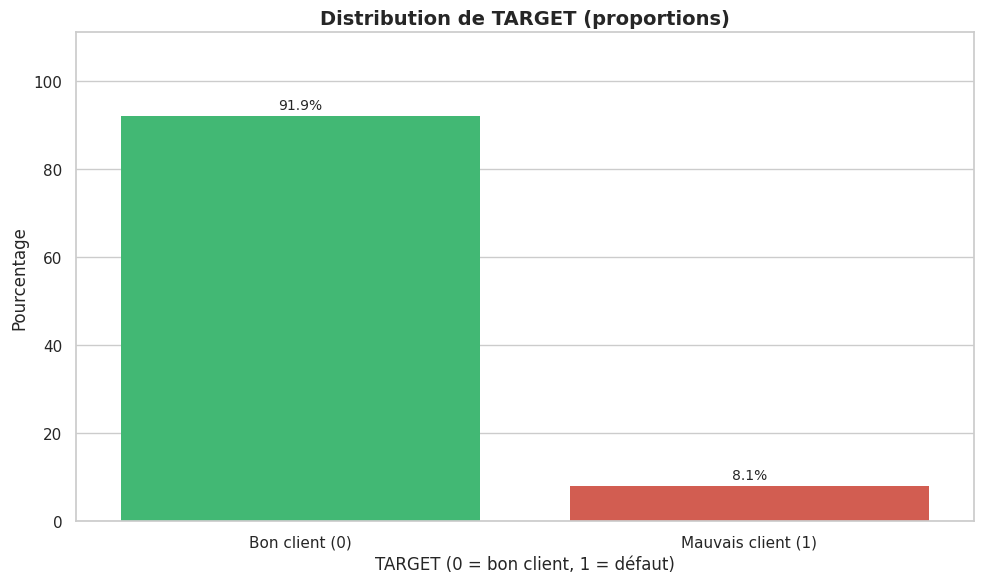

In [6]:
utils.distribution_column(app_train, 'TARGET')
n_maj = app_train[TARGET].value_counts()[0]
n_min = app_train[TARGET].value_counts()[1]
ratio = n_maj / n_min
print(f"Ratio de déséquilibre : {ratio:.1f}:1 ({n_maj} vs {n_min})")


fig, axes = plt.subplots(1, 1, figsize=(10, 6))
vi.create_countplot(
    app_train, axes, x=TARGET,
    hue=TARGET, palette=PALETTE_TARGET,
    normalize=True,
    title='Distribution de TARGET (proportions)',
    xlabel='TARGET (0 = bon client, 1 = défaut)',
    ylabel='Pourcentage',
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
    xrotation=0,
)

plt.tight_layout()
plt.show()


**Observations :**
- Fort déséquilibre des classes : ~91.9% de bons clients (TARGET=0) vs ~8.1% de défauts (TARGET=1), ratio d'environ 11:1.
- Ce déséquilibre est attendu et cohérent avec le contexte métier (la majorité des clients remboursent leur crédit).
- **Impact sur la modélisation** : il faudra utiliser `class_weight='balanced'` ou appliquer du rééchantillonnage (SMOTE) pour éviter que le modèle ignore la classe minoritaire.

### 1.3 Valeurs manquantes — visualisation détaillée
- Barplot horizontal des colonnes avec NaN
- Identifier les colonnes avec >50% de NaN (candidates à la suppression)


🌐 Pourcentage de cellules vides sur tout le DataFrame : 24.40%

📊 Nombre de colonne avec des cellules vides : 67


,Colonne,Valeurs manquantes,Pourcentage (%)
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
...,...,...,...
42,EXT_SOURCE_2,660,0.214626
10,AMT_GOODS_PRICE,278,0.090403
9,AMT_ANNUITY,12,0.003902
29,CNT_FAM_MEMBERS,2,0.000650


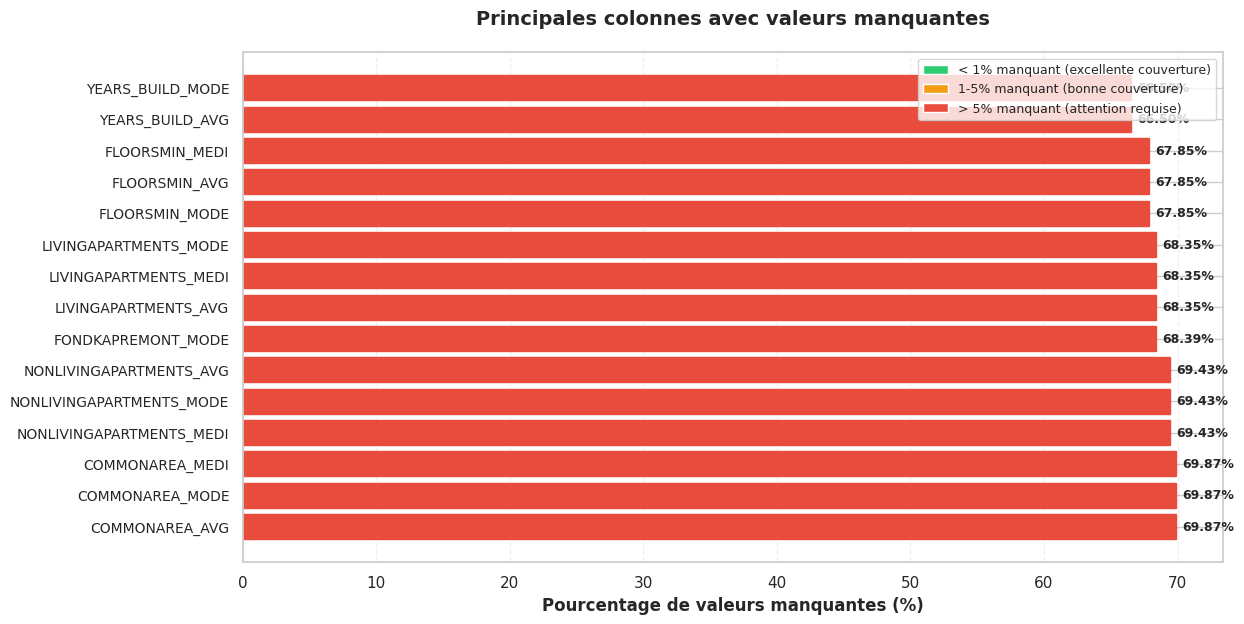

In [7]:
app_train_missing_value = utils.analyze_missing_values(app_train)
display(app_train_missing_value[app_train_missing_value['Pourcentage (%)'] > 0])

vi.plot_missing_values(app_train_missing_value)

**Observations :**
- Plusieurs colonnes présentent un taux de valeurs manquantes très élevé (>50%), notamment les variables liées à la famille et aux biens immobiliers (`OWN_CAR_AGE`, `EXT_SOURCE_1`, colonnes `APARTMENTS_*`, etc.).
- Les colonnes avec >50% de NaN seront candidates à la suppression dans le notebook de preprocessing.
- `EXT_SOURCE_1` est manquante pour ~56% des clients malgré sa forte corrélation avec TARGET — une stratégie d'imputation sera nécessaire.
- **Impact sur le preprocessing** : prévoir une imputation par médiane pour les variables numériques et par mode pour les catégorielles, après avoir filtré les colonnes trop incomplètes.

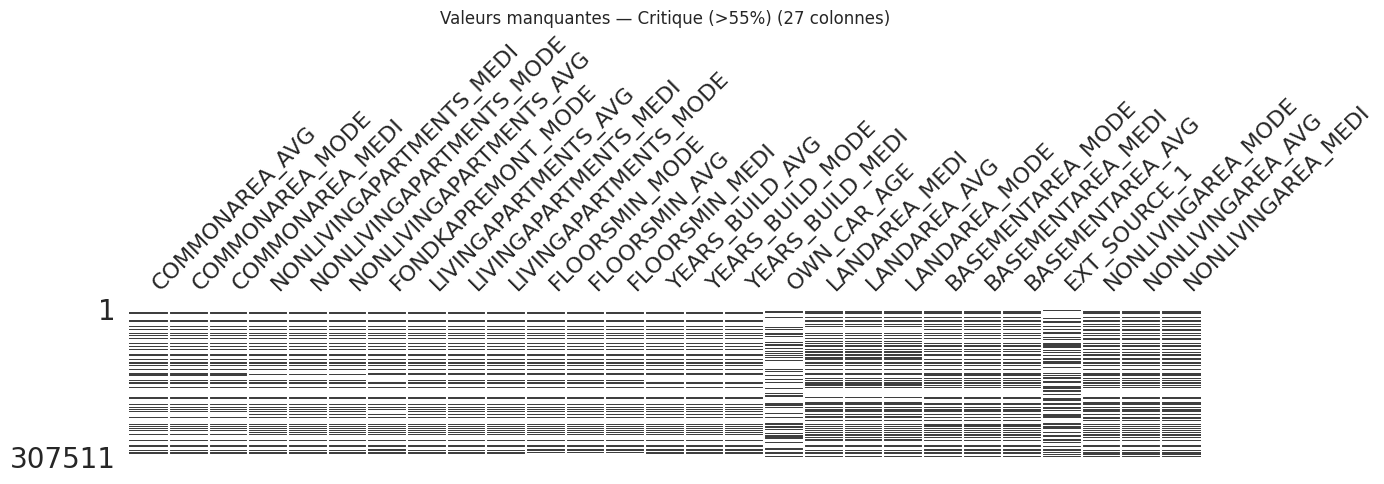

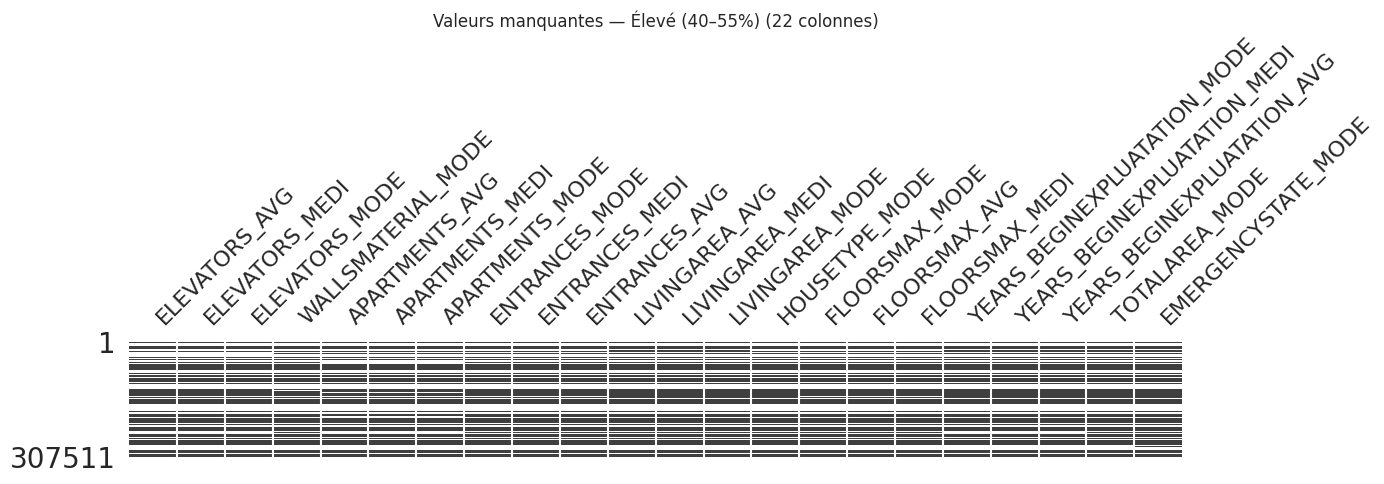

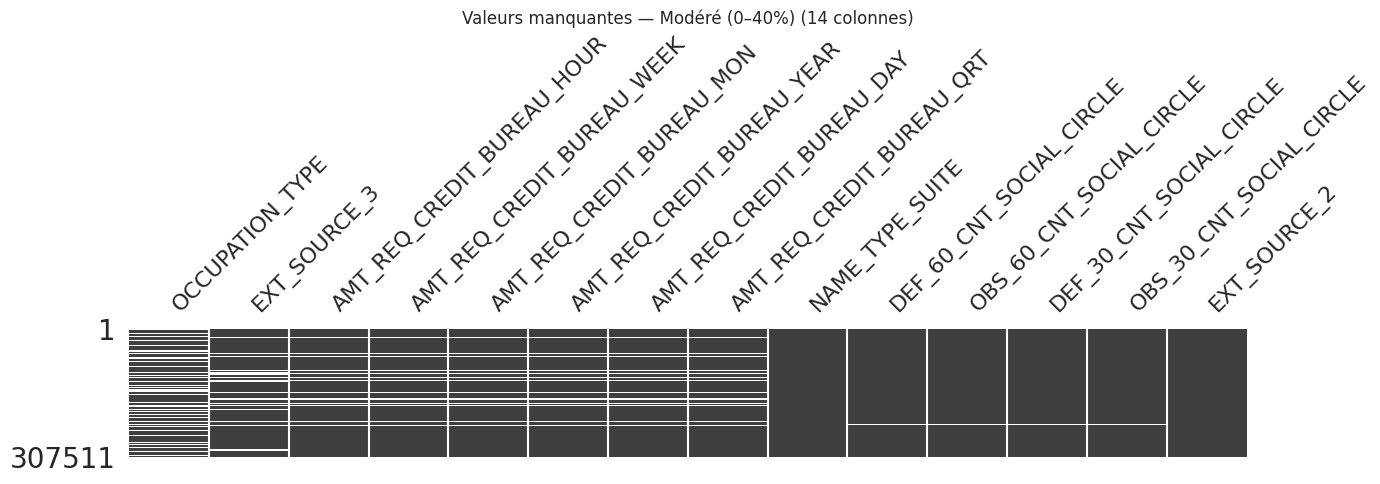

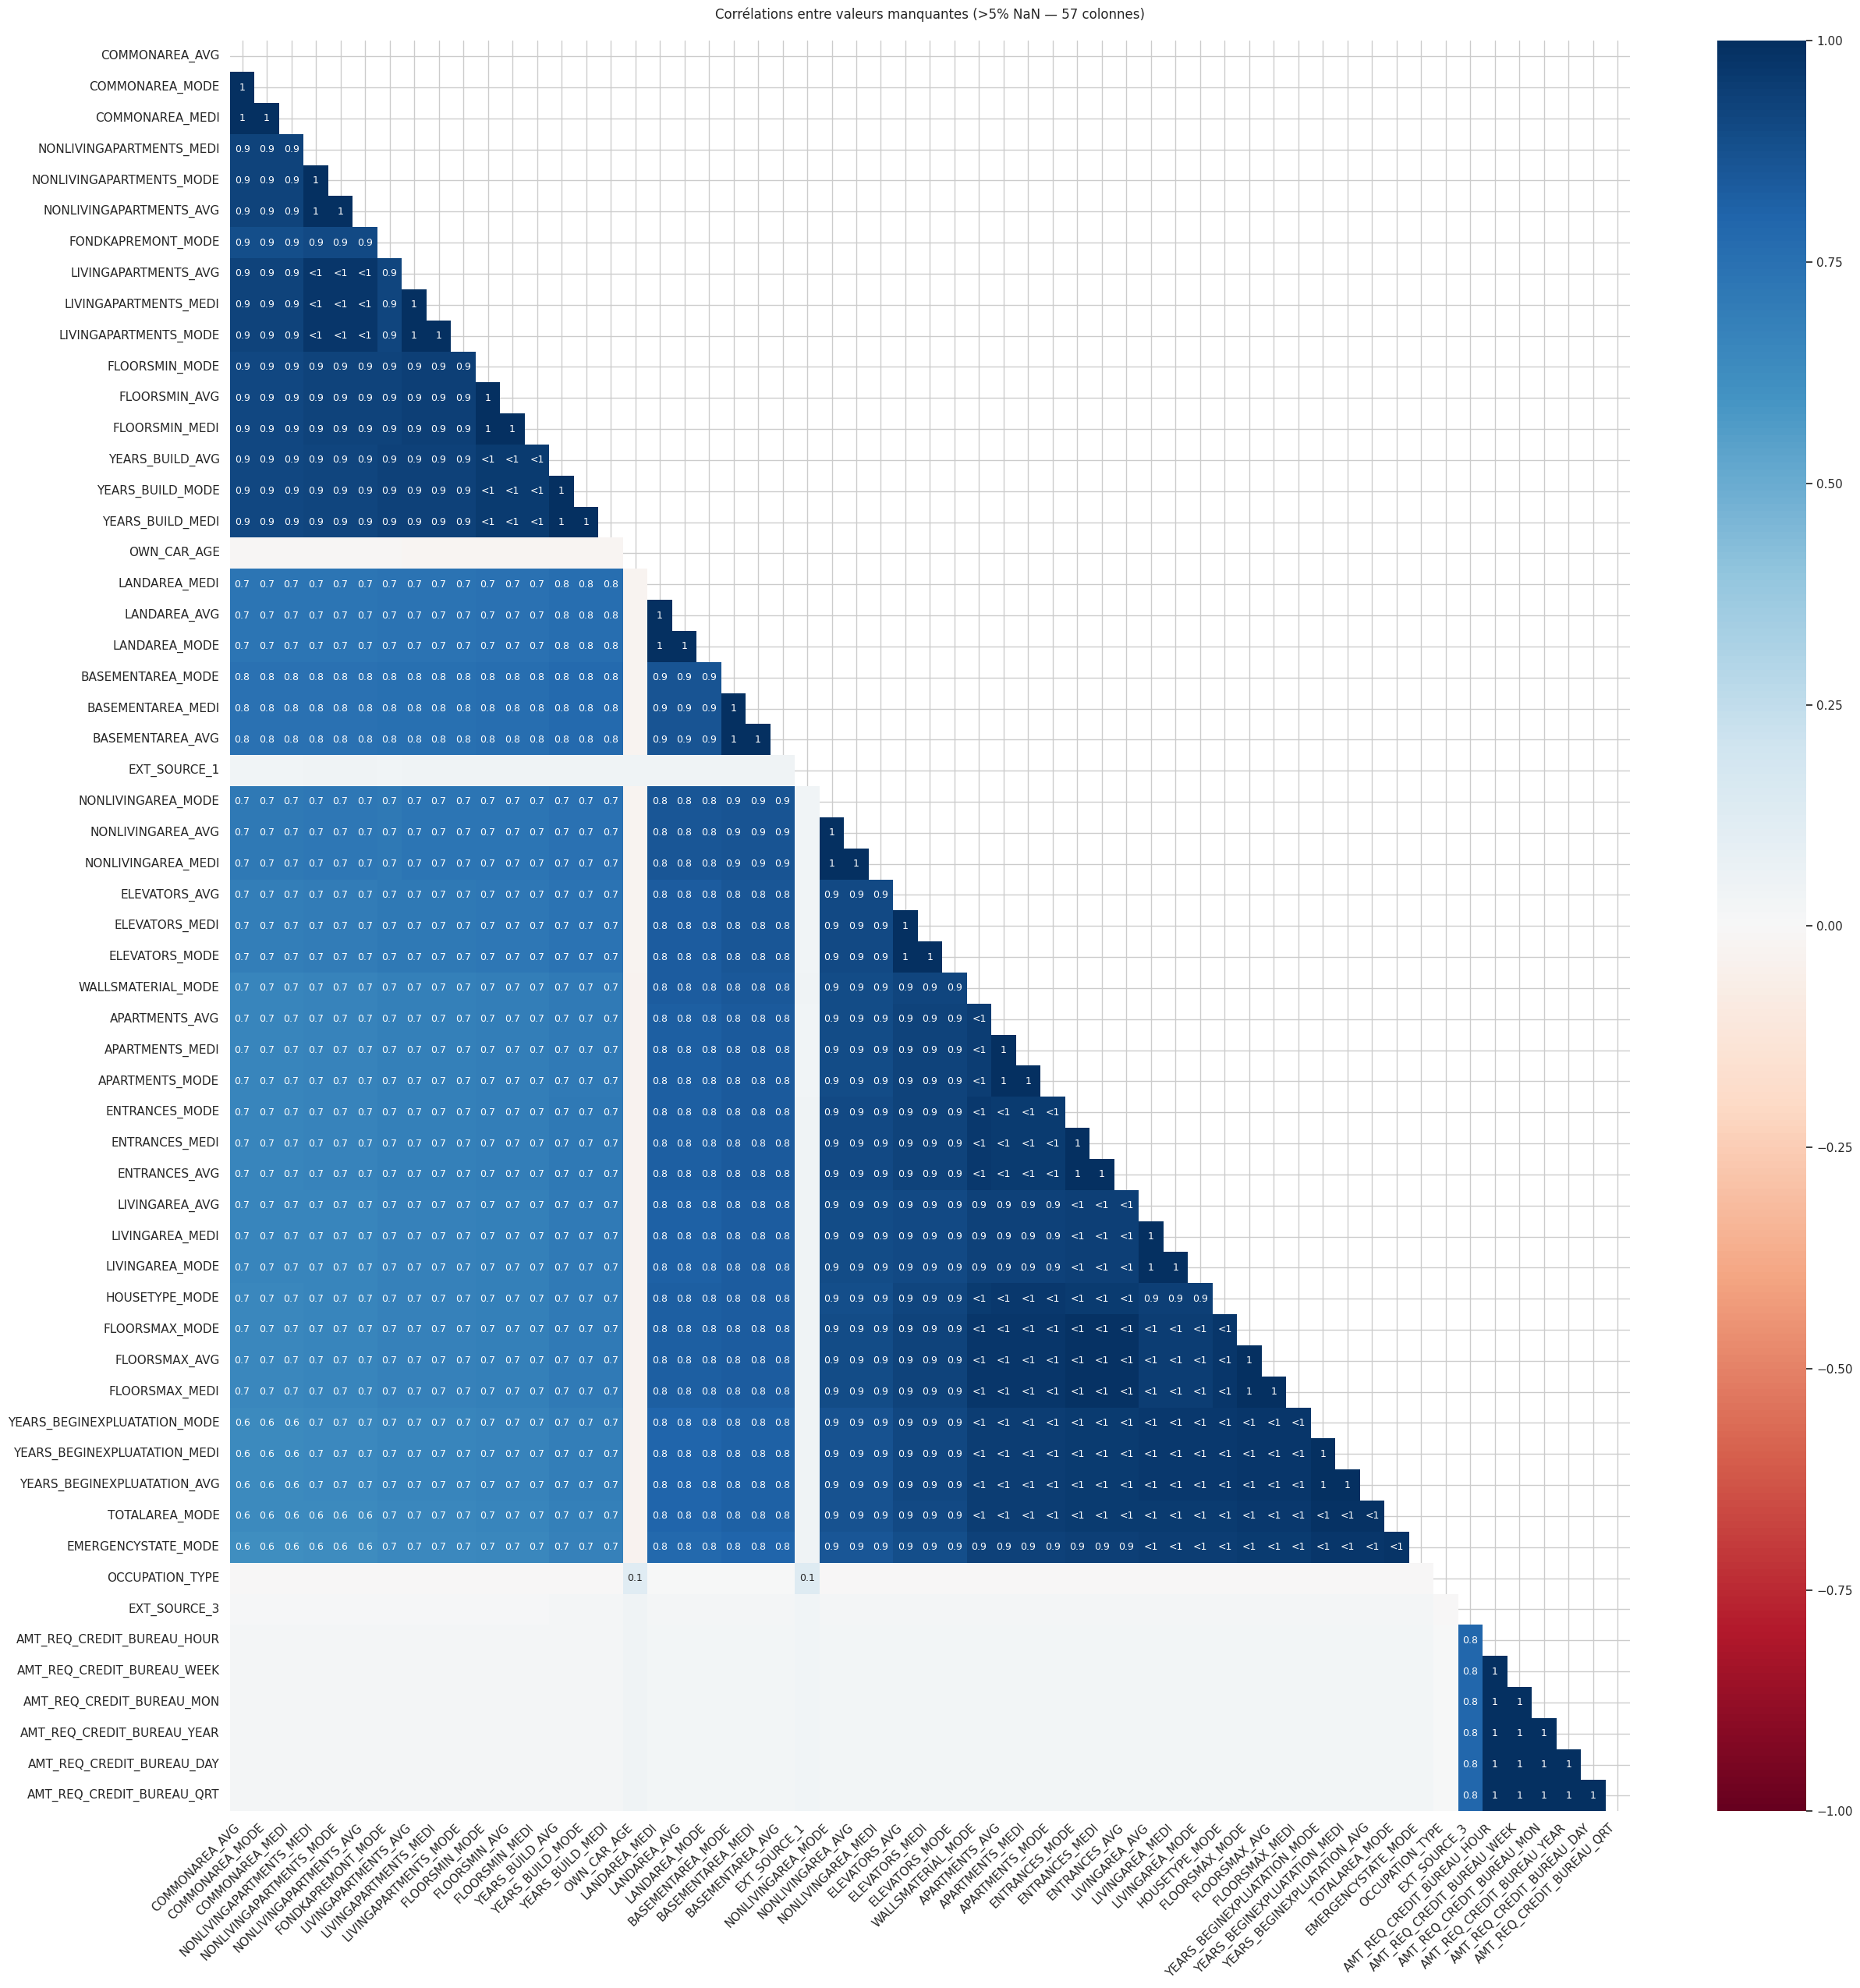

In [ ]:
# --- Matrices par tranche de taux de NaN ---
tranches = {
    "Critique (>55%)":  app_train_missing_value[app_train_missing_value['Pourcentage (%)'] > 55]['Colonne'].tolist(),
    "Élevé (40–55%)":   app_train_missing_value[app_train_missing_value['Pourcentage (%)'].between(40, 55)]['Colonne'].tolist(),
    "Modéré (0–40%)":   app_train_missing_value[app_train_missing_value['Pourcentage (%)'].between(0.1, 40)]['Colonne'].tolist(),
}

for titre, cols in tranches.items():
    if not cols:
        print(f"Aucune colonne dans la tranche : {titre}")
        continue
    fig, ax = plt.subplots(figsize=(14, 5))
    msno.matrix(app_train[cols], ax=ax, sparkline=False)
    ax.set_title(f"Valeurs manquantes — {titre} ({len(cols)} colonnes)")
    plt.tight_layout()
    plt.show()

# --- Heatmap globale : corrélations entre colonnes avec >5% de NaN ---
cols_heatmap = app_train_missing_value[
    app_train_missing_value['Pourcentage (%)'] > 5
]['Colonne'].tolist()

n = len(cols_heatmap)
fig, ax = plt.subplots(figsize=(n * 0.45, n * 0.45))
msno.heatmap(app_train[cols_heatmap], ax=ax, fontsize=11)

ax.set_title(f"Corrélations entre valeurs manquantes (>5% NaN — {n} colonnes)", pad=20)
plt.tight_layout()
plt.show()

**Observations :**
- **Matrices par tranche** : les colonnes de la tranche critique (>55%) présentent des motifs 
  de manquants **structurés** — les variables `APARTMENTS_*`, `LIVINGAREA_*`, `FLOORSMAX_*` 
  sont absentes ensemble pour les mêmes clients (logement non renseigné).
- **Heatmap** : les fortes corrélations entre colonnes `APARTMENTS_*` et `LIVINGAREA_*` 
  confirment leur cooccurrence — elles peuvent être traitées ensemble (suppression groupée 
  ou imputation commune).
- `EXT_SOURCE_1` manque indépendamment des autres EXT_SOURCE → imputation séparée nécessaire.
- **Impact preprocessing** : les colonnes manquantes de façon structurée → imputer à 0 
  ou créer un flag binaire plutôt qu'imputer par médiane.


### 1.4 Variables catégorielles
- Distribution des modalités pour les principales variables (`CODE_GENDER`, `NAME_CONTRACT_TYPE`, `NAME_EDUCATION_TYPE`, etc.)
- Taux de défaut par modalité

In [9]:
utils.distribution_column(app_train, 'CODE_GENDER', target='TARGET', target_label='Taux de défaut (%)')


📊 Distribution de la colonne 'CODE_GENDER'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%),Taux de défaut (%)
CODE_GENDER,,,
F,202448,65.83,6.999
M,105059,34.16,10.142
XNA,4,0.00,0.000


In [10]:
utils.distribution_column(app_train, 'NAME_CONTRACT_TYPE', target='TARGET', target_label='Taux de défaut (%)')


📊 Distribution de la colonne 'NAME_CONTRACT_TYPE'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%),Taux de défaut (%)
NAME_CONTRACT_TYPE,,,
Cash loans,278232,90.48,8.346
Revolving loans,29279,9.52,5.478


In [11]:
utils.distribution_column(app_train, 'NAME_EDUCATION_TYPE', target='TARGET', target_label='Taux de défaut (%)')


📊 Distribution de la colonne 'NAME_EDUCATION_TYPE'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%),Taux de défaut (%)
NAME_EDUCATION_TYPE,,,
Secondary / secondary special,218391,71.02,8.940
Higher education,74863,24.34,5.355
Incomplete higher,10277,3.34,8.485
Lower secondary,3816,1.24,10.928
Academic degree,164,0.05,1.829


In [12]:
utils.distribution_column(app_train, 'NAME_INCOME_TYPE', target='TARGET', target_label='Taux de défaut (%)')


📊 Distribution de la colonne 'NAME_INCOME_TYPE'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%),Taux de défaut (%)
NAME_INCOME_TYPE,,,
Working,158774,51.63,9.588
Commercial associate,71617,23.29,7.484
Pensioner,55362,18.00,5.386
State servant,21703,7.06,5.755
Unemployed,22,0.01,36.364
Student,18,0.01,0.000
Businessman,10,0.00,0.000
Maternity leave,5,0.00,40.000


In [13]:
utils.distribution_column(app_train, 'NAME_FAMILY_STATUS', target='TARGET', target_label='Taux de défaut (%)')


📊 Distribution de la colonne 'NAME_FAMILY_STATUS'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%),Taux de défaut (%)
NAME_FAMILY_STATUS,,,
Married,196432,63.88,7.560
Single / not married,45444,14.78,9.808
Civil marriage,29775,9.68,9.945
Separated,19770,6.43,8.194
Widow,16088,5.23,5.824
Unknown,2,0.00,0.000


In [14]:
utils.distribution_column(app_train, 'NAME_HOUSING_TYPE', target='TARGET', target_label='Taux de défaut (%)')


📊 Distribution de la colonne 'NAME_HOUSING_TYPE'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%),Taux de défaut (%)
NAME_HOUSING_TYPE,,,
House / apartment,272868,88.73,7.796
With parents,14840,4.83,11.698
Municipal apartment,11183,3.64,8.540
Rented apartment,4881,1.59,12.313
Office apartment,2617,0.85,6.572
Co-op apartment,1122,0.36,7.932


**Observations :**
- **Genre** : les hommes ont un taux de défaut plus élevé (10.1%) que les femmes (7.0%). La modalité `XNA` (4 individus) sera à supprimer ou regrouper.
- **Type de contrat** : les prêts revolving sont moins risqués (5.5%) que les prêts classiques (8.3%).
- **Niveau d'éducation** : les diplômés du supérieur défaillent moins (5.4%) ; les niveaux les plus bas (`Lower secondary`) sont les plus risqués (10.9%).
- **Type de revenu** : les chômeurs et les personnes en congé maternité affichent des taux très élevés (36% et 40%) mais sur des effectifs quasi nuls — à interpréter avec prudence.
- **Logement** : les locataires ont le taux de défaut le plus élevé (12.3%), les propriétaires le plus bas.
- **Impact sur le preprocessing** : encoder ces variables catégorielles (One-Hot ou ordinal selon la nature), et traiter les modalités rares.

### 1.5 Distributions des variables numériques & anomalies
- Distributions des variables clés (revenus, montants de crédit, âge)
- Anomalie connue : `DAYS_EMPLOYED = 365243` → flag + remplacement par NaN
- Autres outliers (`AMT_INCOME_TOTAL`, `DAYS_BIRTH`, etc.)

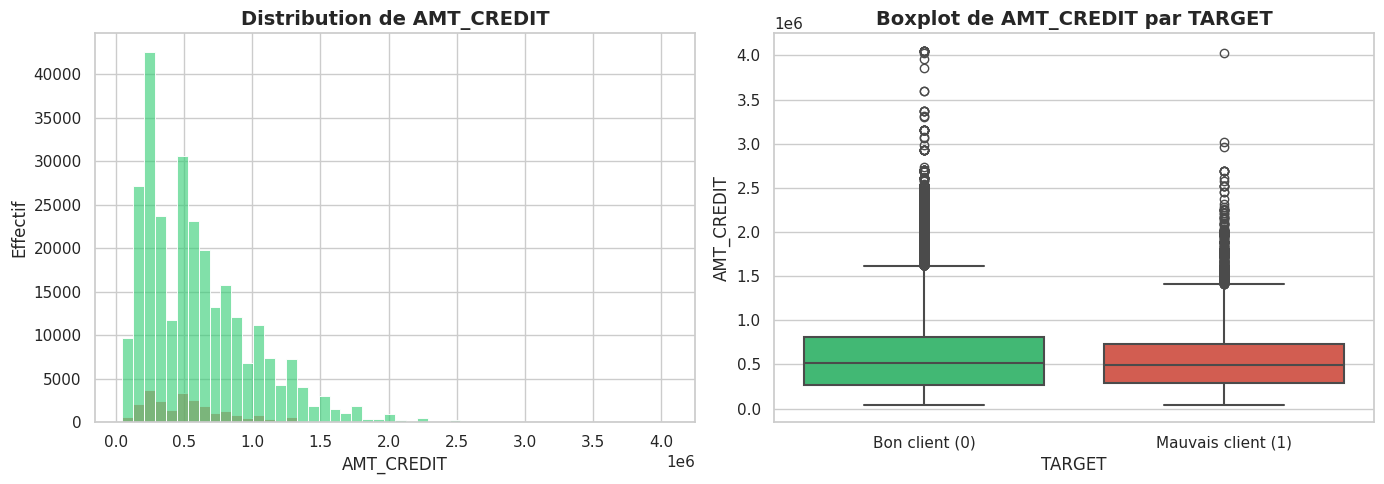

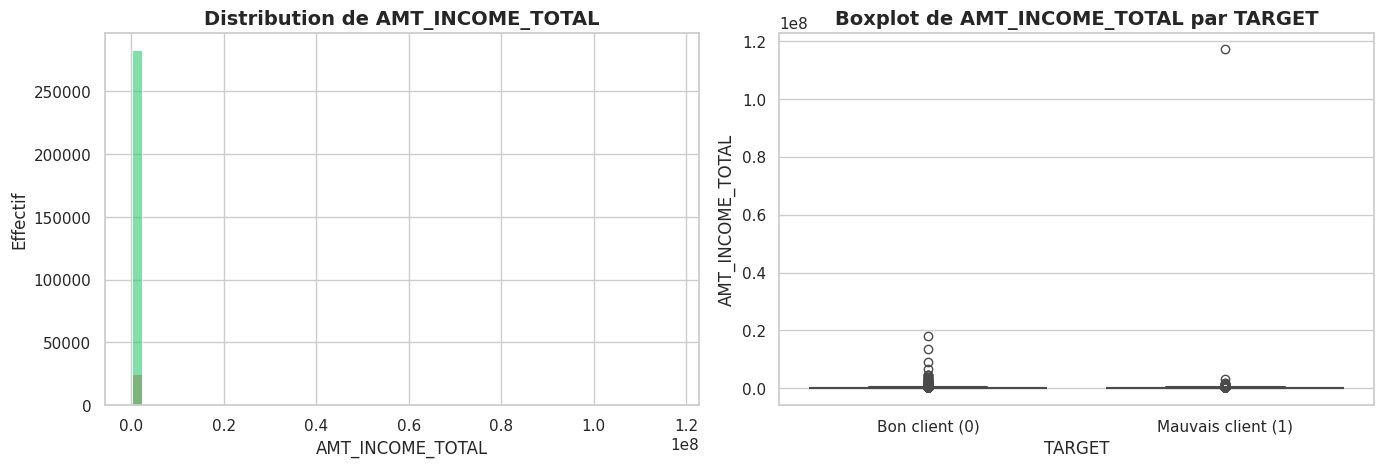

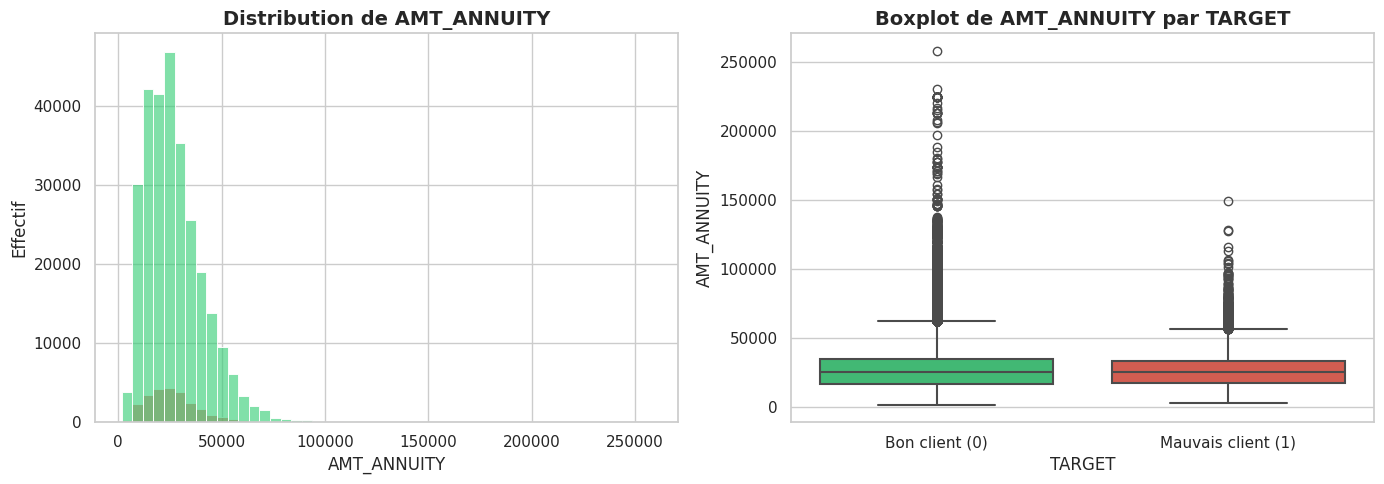

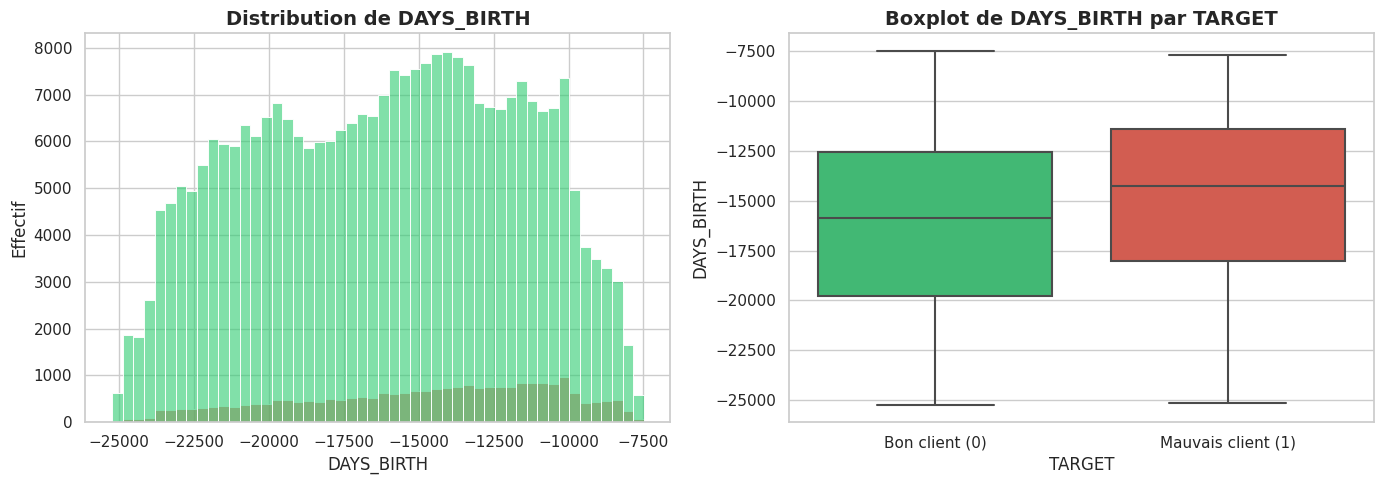

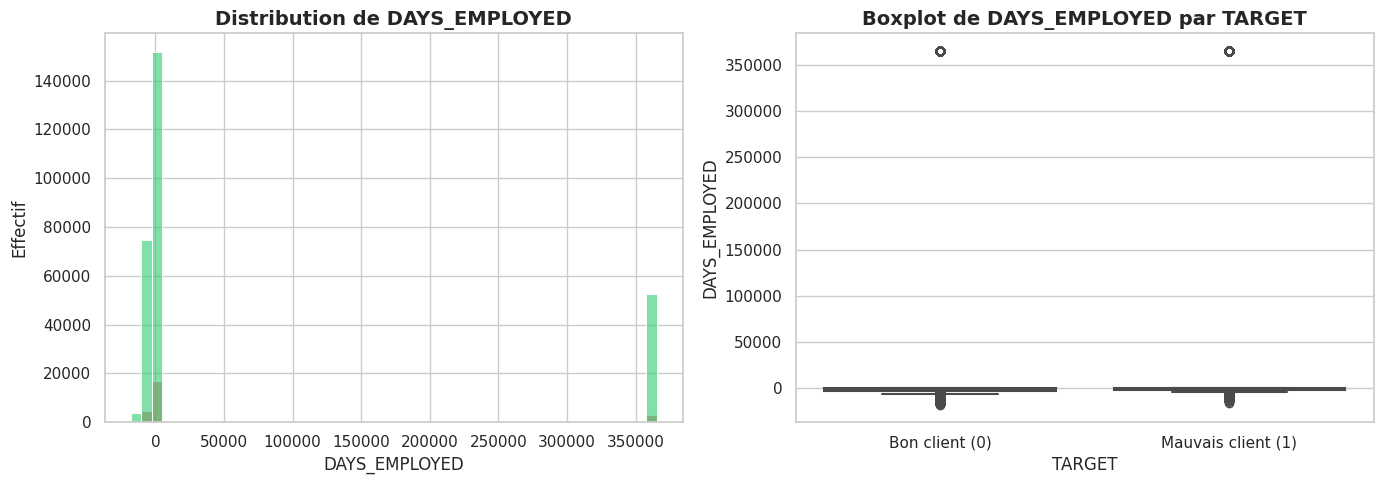

In [15]:
# --- AMT_CREDIT — Montant du crédit demandé ---
cols = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY' , 'DAYS_BIRTH', 'DAYS_EMPLOYED']

def plot_num_vs_target(df, col):
    _, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histogramme splitté par TARGET
    vi.create_histplot(
        df, axes[0], x=col,
        hue='TARGET', palette=PALETTE_TARGET,
        title=f'Distribution de {col}',
        xlabel=col, ylabel='Effectif',
    )


    # Boxplot splitté par TARGET
    vi.create_boxplot(
        df, axes[1],
        x='TARGET', y=col,
        hue='TARGET', palette=PALETTE_TARGET,
        title=f'Boxplot de {col} par TARGET',
        xlabel='TARGET', ylabel=col,
        xticklabels=['Bon client (0)', 'Mauvais client (1)'],
    )

    plt.tight_layout()
    plt.show()


for col in cols:
    plot_num_vs_target(app_train, col)

**Observations :**
- **`AMT_CREDIT` / `AMT_ANNUITY`** : distributions étalées à droite avec quelques valeurs extrêmes — une transformation log sera envisagée.
- **`AMT_INCOME_TOTAL`** : quelques revenus extrêmement élevés (outliers manifestes) qui pourraient biaiser les modèles linéaires.
- **`DAYS_BIRTH`** (âge en jours négatifs) : distribution normale, pas d'anomalie détectée. Les clients plus âgés semblent moins risqués.
- **`DAYS_EMPLOYED`** : présence de la valeur aberrante `365243` correspondant à des retraités/sans emploi mal encodés. Cette valeur devra être remplacée par `NaN` puis imputée dans le preprocessing.
- **Impact sur le preprocessing** : créer une variable `AGE_YEARS = -DAYS_BIRTH / 365`, flagguer les `DAYS_EMPLOYED == 365243`, et envisager un cap sur `AMT_INCOME_TOTAL`.

### 1.6 Corrélations avec `TARGET`
- Top features corrélées (Pearson, tri par valeur absolue)
- Focus sur `EXT_SOURCE_1/2/3` (variables très prédictives)
- Matrice de corrélation (top N variables numériques)

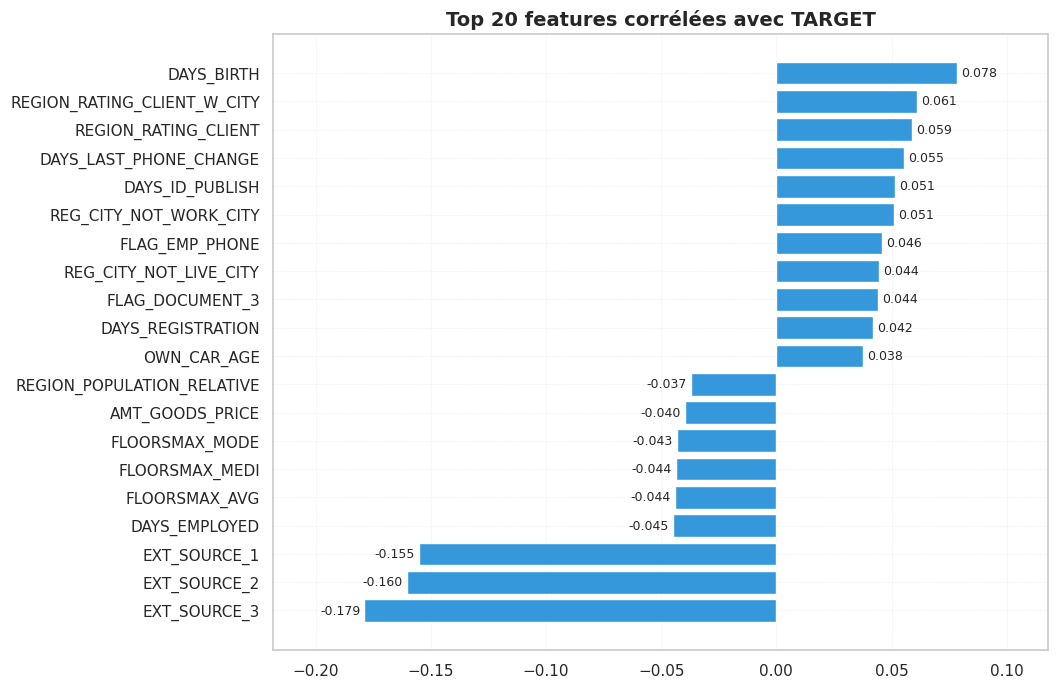

In [16]:
corr = app_train.select_dtypes('number').corr()['TARGET'].drop('TARGET')
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

df_corr = corr_sorted.head(20).reset_index()
df_corr.columns = ['Feature', 'Corrélation']

fig, ax = plt.subplots(figsize=(10, 8))
vi.create_barh(df_corr, ax, x='Corrélation', y='Feature',
               title='Top 20 features corrélées avec TARGET')
plt.show()


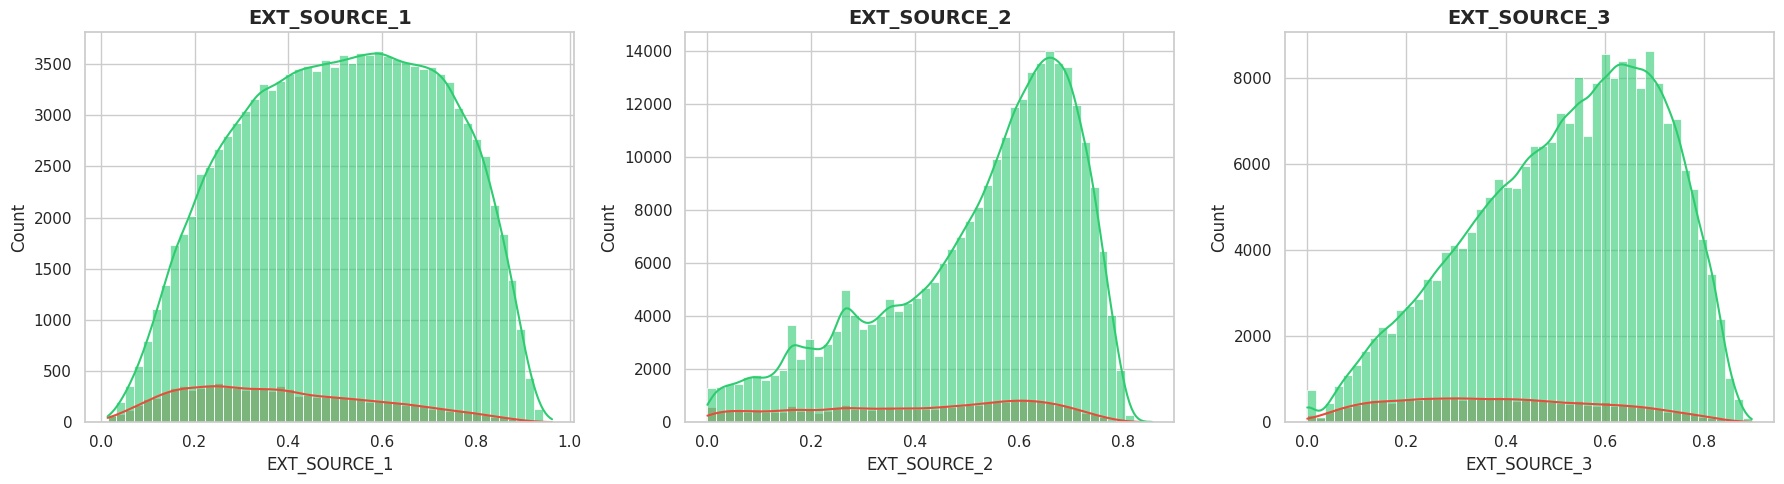

In [17]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ext_cols):
    vi.create_histplot(
        app_train, ax, x=col,
        hue='TARGET', palette=PALETTE_TARGET,
        title=col, xlabel=col, kde=True
    )
plt.tight_layout()
plt.show()


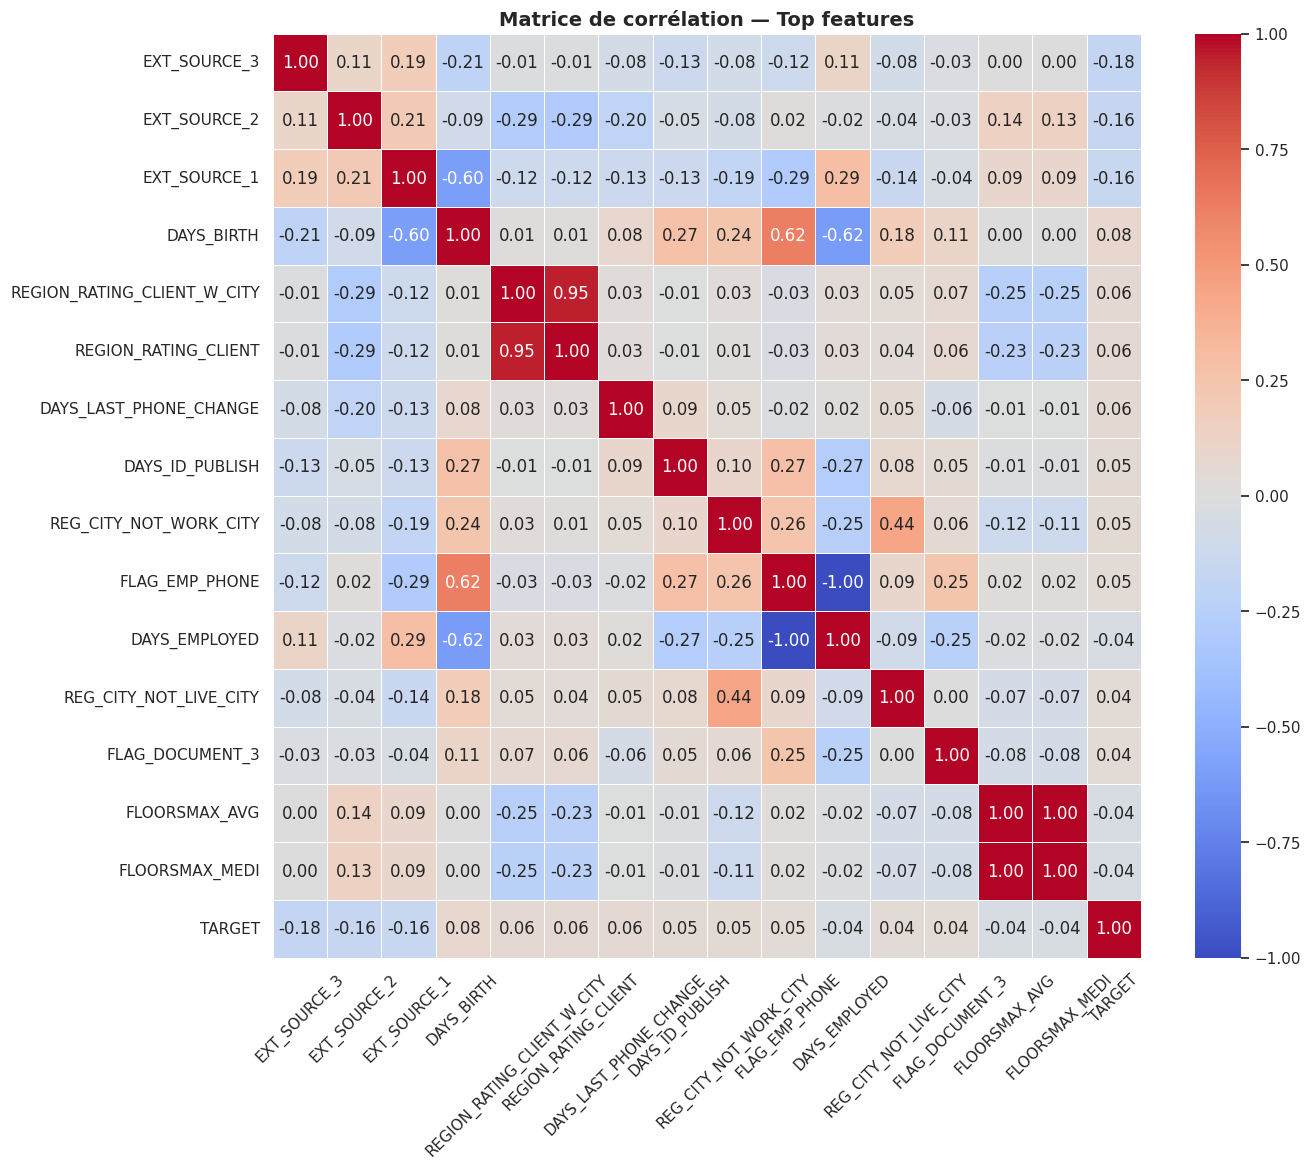

In [18]:
top_features = corr_sorted.head(15).index.tolist() + ['TARGET']

fig, ax = plt.subplots(figsize=(14, 12))
vi.create_heatmap(
    app_train[top_features].corr(), ax,
    title='Matrice de corrélation — Top features',
    fmt='.2f', vmin=-1, vmax=1, center=0
)
plt.show()


**Observations :**
- Les variables `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3` sont les features les plus corrélées avec TARGET (corrélations négatives : plus le score est élevé, moins le client est risqué). Ce sont très probablement des scores de crédit externes.
- `DAYS_BIRTH` (âge) est également parmi les features les plus discriminantes.
- Les corrélations restent modérées (max ~0.25 en valeur absolue) — cohérent avec un problème complexe nécessitant un modèle non-linéaire.
- **Impact sur la modélisation** : `EXT_SOURCE_1/2/3` seront des features à conserver en priorité ; leur imputation doit être soignée.

---
### 1.7 Features dérivées — ratios issus du kernel Kaggle

Le kernel de référence (`lightgbm_with_simple_features.py`) crée 5 ratios à partir des variables de la table principale.
L'objectif ici est de **vérifier leur corrélation avec TARGET** avant de les intégrer dans le preprocessing.

| Feature | Formule | Intuition métier |
|---|---|---|
| `DAYS_EMPLOYED_PERC` | `DAYS_EMPLOYED / DAYS_BIRTH` | Durée d'emploi relative à l'âge |
| `INCOME_CREDIT_PERC` | `AMT_INCOME_TOTAL / AMT_CREDIT` | Capacité de remboursement |
| `INCOME_PER_PERSON` | `AMT_INCOME_TOTAL / CNT_FAM_MEMBERS` | Revenu par membre du foyer |
| `ANNUITY_INCOME_PERC` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | Part du revenu consacrée aux annuités |
| `PAYMENT_RATE` | `AMT_ANNUITY / AMT_CREDIT` | Taux de remboursement mensuel |

In [19]:
# Création des 5 ratios sur une copie pour ne pas modifier app_train
# Note : DAYS_EMPLOYED contient encore la valeur aberrante 365243 → remplacée par NaN pour le calcul
df_ratios = app_train[['TARGET', 'DAYS_EMPLOYED', 'DAYS_BIRTH',
                         'AMT_INCOME_TOTAL', 'AMT_CREDIT',
                         'CNT_FAM_MEMBERS', 'AMT_ANNUITY']].copy()

df_ratios['DAYS_EMPLOYED'] = df_ratios['DAYS_EMPLOYED'].replace(365243, np.nan)

df_ratios['DAYS_EMPLOYED_PERC']  = df_ratios['DAYS_EMPLOYED']   / df_ratios['DAYS_BIRTH']
df_ratios['INCOME_CREDIT_PERC']  = df_ratios['AMT_INCOME_TOTAL'] / df_ratios['AMT_CREDIT']
df_ratios['INCOME_PER_PERSON']   = df_ratios['AMT_INCOME_TOTAL'] / df_ratios['CNT_FAM_MEMBERS']
df_ratios['ANNUITY_INCOME_PERC'] = df_ratios['AMT_ANNUITY']     / df_ratios['AMT_INCOME_TOTAL']
df_ratios['PAYMENT_RATE']        = df_ratios['AMT_ANNUITY']      / df_ratios['AMT_CREDIT']

ratio_cols = ['DAYS_EMPLOYED_PERC', 'INCOME_CREDIT_PERC', 'INCOME_PER_PERSON',
              'ANNUITY_INCOME_PERC', 'PAYMENT_RATE']

print('Features créées, aperçu des NaN :')
print(df_ratios[ratio_cols].isnull().sum())

Features créées, aperçu des NaN :
DAYS_EMPLOYED_PERC     55374
INCOME_CREDIT_PERC         0
INCOME_PER_PERSON          2
ANNUITY_INCOME_PERC       12
PAYMENT_RATE              12
dtype: int64


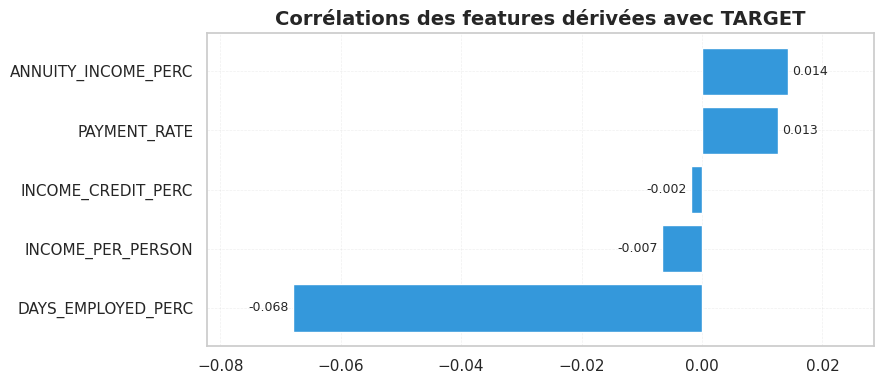

            Feature  Corrélation
 DAYS_EMPLOYED_PERC    -0.067955
ANNUITY_INCOME_PERC     0.014265
       PAYMENT_RATE     0.012704
  INCOME_PER_PERSON    -0.006571
 INCOME_CREDIT_PERC    -0.001817


In [20]:
# Corrélations des 5 ratios avec TARGET
corr_ratios = df_ratios[ratio_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
corr_ratios_sorted = corr_ratios.reindex(corr_ratios.abs().sort_values(ascending=False).index)

df_corr_ratios = corr_ratios_sorted.reset_index()
df_corr_ratios.columns = ['Feature', 'Corrélation']

fig, ax = plt.subplots(figsize=(9, 4))
vi.create_barh(df_corr_ratios, ax, x='Corrélation', y='Feature',
               title='Corrélations des features dérivées avec TARGET')
plt.tight_layout()
plt.show()

print(df_corr_ratios.to_string(index=False))

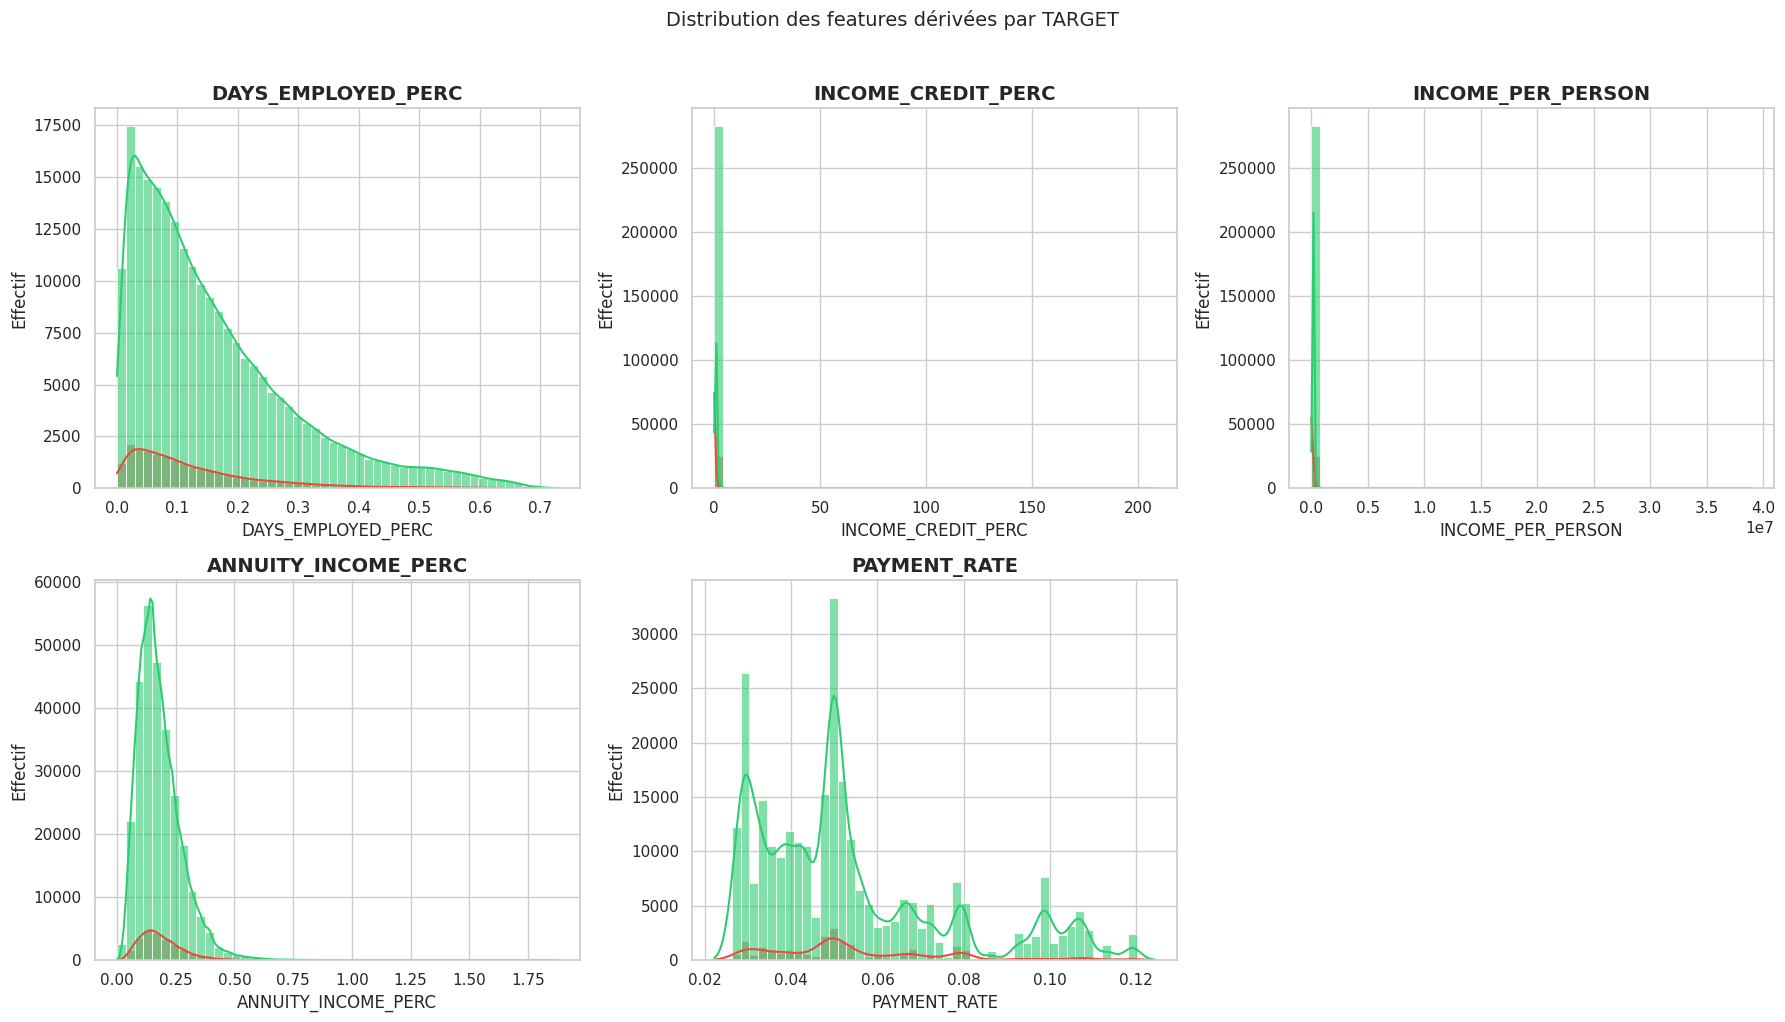

In [21]:
# Distribution de chaque ratio splitté par TARGET
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(ratio_cols):
    vi.create_histplot(
        df_ratios, axes[i], x=col,
        hue='TARGET', palette=PALETTE_TARGET,
        title=col, xlabel=col, ylabel='Effectif', kde=True,
    )

# Masquer la 6e case (grille 2x3 pour 5 features)
axes[5].set_visible(False)

plt.suptitle('Distribution des features dérivées par TARGET', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations :**
- **`DAYS_EMPLOYED_PERC` (-0.068)** : le ratio le plus discriminant — la durée d'emploi rapportée à l'âge est un bon signal de stabilité professionnelle. À conserver en priorité.
- **`ANNUITY_INCOME_PERC` (0.014) et `PAYMENT_RATE` (0.013)** : corrélations linéaires faibles, mais ces ratios capturent une charge financière relative qui peut être utile aux modèles non-linéaires (LightGBM, XGBoost) même si Pearson ne le détecte pas.
- **`INCOME_PER_PERSON` (-0.007) et `INCOME_CREDIT_PERC` (-0.002)** : signal quasi nul — probablement redondants avec les variables brutes `AMT_INCOME_TOTAL` et `AMT_CREDIT` déjà présentes.
- **À noter** : ces corrélations sont bien inférieures à celles de `EXT_SOURCE_1/2/3` (~0.15–0.25) et `DAYS_BIRTH` (~0.08). Les ratios du kernel n'apportent pas de signal fort en eux-mêmes.
- **Décision preprocessing** : conserver `DAYS_EMPLOYED_PERC`, `ANNUITY_INCOME_PERC` et `PAYMENT_RATE` pour leur potentiel non-linéaire. Laisser de côté `INCOME_PER_PERSON` et `INCOME_CREDIT_PERC` pour éviter la redondance.

### 1.7 Comparaison train / test
- Vérification de la cohérence des colonnes (hors `TARGET`)
- Comparaison des distributions des features clés (data drift potentiel)

In [22]:
cols_train = set(app_train.columns) - {'TARGET'}
cols_test  = set(app_test.columns)

print("Colonnes dans train mais pas dans test :", cols_train - cols_test)
print("Colonnes dans test mais pas dans train :", cols_test - cols_train)
print(f"\nShapes — Train : {app_train.shape} | Test : {app_test.shape}")


Colonnes dans train mais pas dans test : set()
Colonnes dans test mais pas dans train : set()

Shapes — Train : (307511, 122) | Test : (48744, 121)


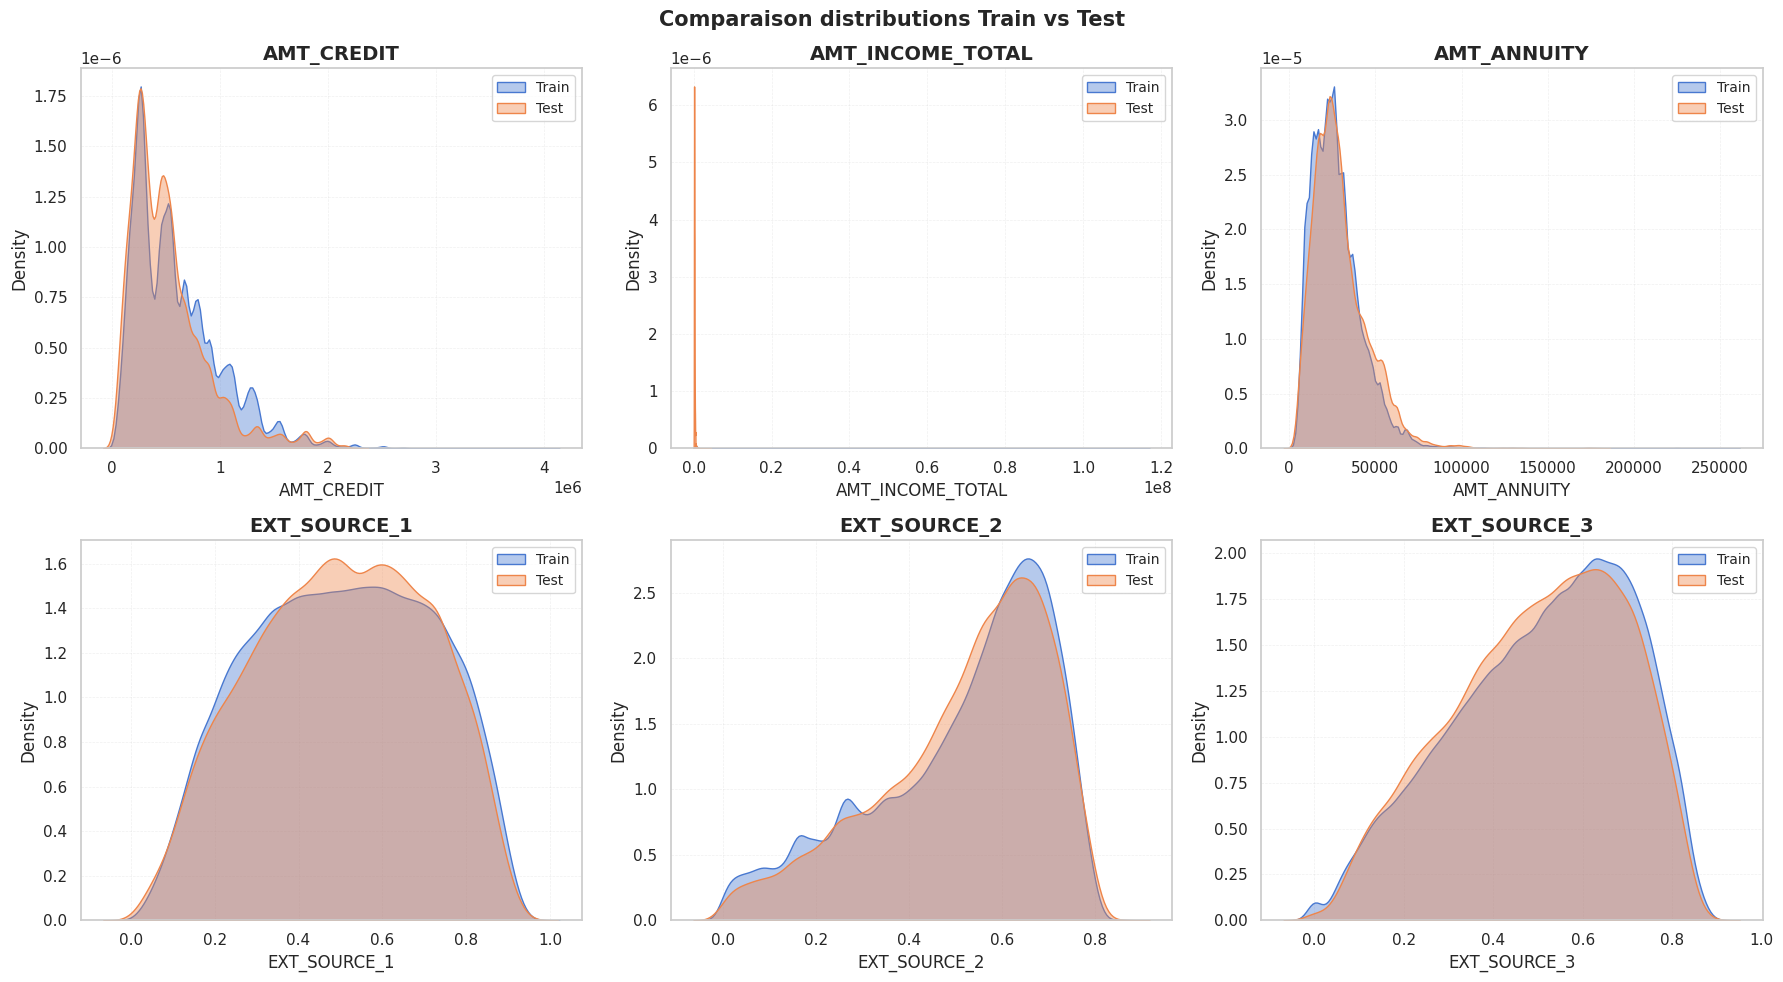

In [23]:
cols_a_comparer = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
                   'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, cols_a_comparer):
    vi.plot_distributions({'Train': app_train, 'Test': app_test}, col, ax)

plt.suptitle('Comparaison distributions Train vs Test', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations :**
- Les colonnes sont identiques entre train et test (hors `TARGET` absente du test), aucune colonne orpheline.
- Les distributions des variables clés (`AMT_CREDIT`, `AMT_INCOME_TOTAL`, `AMT_ANNUITY`, `EXT_SOURCE_1/2/3`) sont visuellement très proches entre train et test → **pas de data drift apparent**.
- Le jeu de test représente ~13.7% du total, ce qui est raisonnable.
- **Conclusion** : le preprocessing pourra être appliqué de façon uniforme sur train et test.

---
## 2. `bureau.csv` & `bureau_balance.csv` — Historique crédits externes

### 2.1 Chargement & aperçu complet
- `explore_dataframe()` → shape, NaN, types de variables
- Taux de matching sur `SK_ID_CURR`
- Nombre de crédits externes par client (cardinalité)
- Types de crédits (`CREDIT_TYPE`), statuts (`CREDIT_ACTIVE`), montants, durées

In [24]:
# Chargement des tables bureau
bureau          = pd.read_csv(DATA_RAW + "bureau.csv")
bureau_balance  = pd.read_csv(DATA_RAW + "bureau_balance.csv")

utils.explore_dataframe(bureau)

📋 INFORMATIONS GÉNÉRALES
• Lignes    : 1716428
• Colonnes : 17

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           str    
 3   CREDIT_CURRENCY         str    
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             str    
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), str(3)
memory usage: 222.6 MB

--- DESCRIBE ---


,SK_ID_CURR,SK_ID_BUREAU,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
count,1.716428e+06,1.716428e+06,1.716428e+06,1.716428e+06,1.610875e+06,1.082775e+06,5.919400e+05,1.716428e+06,1.716415e+06,1.458759e+06,1.124648e+06,1.716428e+06,1.716428e+06,4.896370e+05
mean,2.782149e+05,5.924434e+06,-1.142108e+03,8.181666e-01,5.105174e+02,-1.017437e+03,3.825418e+03,6.410406e-03,3.549946e+05,1.370851e+05,6.229515e+03,3.791276e+01,-5.937483e+02,1.571276e+04
std,1.029386e+05,5.322657e+05,7.951649e+02,3.654443e+01,4.994220e+03,7.140106e+02,2.060316e+05,9.622391e-02,1.149811e+06,6.774011e+05,4.503203e+04,5.937650e+03,7.207473e+02,3.258269e+05
min,1.000010e+05,5.000000e+06,-2.922000e+03,0.000000e+00,-4.206000e+04,-4.202300e+04,0.000000e+00,0.000000e+00,0.000000e+00,-4.705600e+06,-5.864061e+05,0.000000e+00,-4.194700e+04,0.000000e+00
25%,1.888668e+05,5.463954e+06,-1.666000e+03,0.000000e+00,-1.138000e+03,-1.489000e+03,0.000000e+00,0.000000e+00,5.130000e+04,0.000000e+00,0.000000e+00,0.000000e+00,-9.080000e+02,0.000000e+00
50%,2.780550e+05,5.926304e+06,-9.870000e+02,0.000000e+00,-3.300000e+02,-8.970000e+02,0.000000e+00,0.000000e+00,1.255185e+05,0.000000e+00,0.000000e+00,0.000000e+00,-3.950000e+02,0.000000e+00
75%,3.674260e+05,6.385681e+06,-4.740000e+02,0.000000e+00,4.740000e+02,-4.250000e+02,0.000000e+00,0.000000e+00,3.150000e+05,4.015350e+04,0.000000e+00,0.000000e+00,-3.300000e+01,1.350000e+04
max,4.562550e+05,6.843457e+06,0.000000e+00,2.792000e+03,3.119900e+04,0.000000e+00,1.159872e+08,9.000000e+00,5.850000e+08,1.701000e+08,4.705600e+06,3.756681e+06,3.720000e+02,1.184534e+08



--- MISSING VALUES ---

🌐 Pourcentage de cellules vides sur tout le DataFrame : 13.50%

📊 Nombre de colonne avec des cellules vides : 7


,Colonne,Valeurs manquantes,Pourcentage (%)
16,AMT_ANNUITY,1226791,71.47
8,AMT_CREDIT_MAX_OVERDUE,1124488,65.51
7,DAYS_ENDDATE_FACT,633653,36.92
12,AMT_CREDIT_SUM_LIMIT,591780,34.48
11,AMT_CREDIT_SUM_DEBT,257669,15.01



=== CLASSIFICATION DES VARIABLES ===
QUANTITATIVE (13): ['AMT_ANNUITY', 'AMT_CREDIT_MAX_OVERDUE', 'AMT_CREDIT_SUM', 'AMT_CREDIT_SUM_DEBT', 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'CREDIT_DAY_OVERDUE', 'DAYS_CREDIT', 'DAYS_CREDIT_ENDDATE', 'DAYS_CREDIT_UPDATE', 'DAYS_ENDDATE_FACT', 'SK_ID_BUREAU', 'SK_ID_CURR']
QUALITATIVE  (3): ['CREDIT_ACTIVE', 'CREDIT_CURRENCY', 'CREDIT_TYPE']
ORDINAL      (1): ['CNT_CREDIT_PROLONG']
DATETIME     (0): []

=== DUPLICATES ===
Lignes totales  : 1716428
Lignes dupliquées: 0
Taux            : 0.00%


In [25]:
# Taux de matching sur SK_ID_CURR
clients_train  = set(app_train['SK_ID_CURR'])
clients_bureau = set(bureau['SK_ID_CURR'])
matching = len(clients_train & clients_bureau) / len(clients_train) * 100
print(f"Clients du train présents dans bureau : {matching:.1f}%")

# Nombre de crédits externes par client (cardinalité)
nb_credits = bureau.groupby('SK_ID_CURR').size()
print(f"\nNombre de crédits externes par client :")
print(nb_credits.describe().round(1))

# Types de crédits et statuts actifs
utils.distribution_column(bureau, 'CREDIT_TYPE')
utils.distribution_column(bureau, 'CREDIT_ACTIVE')

Clients du train présents dans bureau : 85.7%

Nombre de crédits externes par client :
count    305811.0
mean          5.6
std           4.4
min           1.0
25%           2.0
50%           4.0
75%           8.0
max         116.0
dtype: float64

📊 Distribution de la colonne 'CREDIT_TYPE'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
CREDIT_TYPE,,
Consumer credit,1251615,72.92
Credit card,402195,23.43
Car loan,27690,1.61
Mortgage,18391,1.07
Microloan,12413,0.72
Loan for business development,1975,0.12
Another type of loan,1017,0.06
Unknown type of loan,555,0.03
Loan for working capital replenishment,469,0.03



📊 Distribution de la colonne 'CREDIT_ACTIVE'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
CREDIT_ACTIVE,,
Closed,1079273,62.88
Active,630607,36.74
Sold,6527,0.38
Bad debt,21,0.00


### 2.2 `bureau_balance` — Suivi mensuel
- `explore_dataframe()` → shape, NaN, types
- Statuts mensuels (`STATUS`), durée de suivi par crédit
- Distribution des statuts (retards, clôtures)

In [26]:
utils.explore_dataframe(bureau_balance)

# Distribution des statuts mensuels (0=pas de défaut, 1-5=retard, C=clôturé, X=inconnu)
utils.distribution_column(bureau_balance, 'STATUS')

# Durée de suivi par crédit (nb de mois de relevés)
duree_par_credit = bureau_balance.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].count()
print(f"\nDurée de suivi par crédit (nb de mois) :")
print(duree_par_credit.describe().round(1))

📋 INFORMATIONS GÉNÉRALES
• Lignes    : 27299925
• Colonnes : 3

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype
---  ------          -----
 0   SK_ID_BUREAU    int64
 1   MONTHS_BALANCE  int64
 2   STATUS          str  
dtypes: int64(2), str(1)
memory usage: 624.8 MB

--- DESCRIBE ---


,SK_ID_BUREAU,MONTHS_BALANCE
count,2.729992e+07,2.729992e+07
mean,6.036297e+06,-3.074169e+01
std,4.923489e+05,2.386451e+01
min,5.001709e+06,-9.600000e+01
25%,5.730933e+06,-4.600000e+01
50%,6.070821e+06,-2.500000e+01
75%,6.431951e+06,-1.100000e+01
max,6.842888e+06,0.000000e+00



--- MISSING VALUES ---

🌐 Pourcentage de cellules vides sur tout le DataFrame : 0.00%

📊 Nombre de colonne avec des cellules vides : 0


,Colonne,Valeurs manquantes,Pourcentage (%)
0,SK_ID_BUREAU,0,0.0
1,MONTHS_BALANCE,0,0.0
2,STATUS,0,0.0



=== CLASSIFICATION DES VARIABLES ===
QUANTITATIVE (2): ['MONTHS_BALANCE', 'SK_ID_BUREAU']
QUALITATIVE  (1): ['STATUS']
ORDINAL      (0): []
DATETIME     (0): []

=== DUPLICATES ===
Lignes totales  : 27299925
Lignes dupliquées: 0
Taux            : 0.00%

📊 Distribution de la colonne 'STATUS'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
STATUS,,
C,13646993,49.99
0,7499507,27.47
X,5810482,21.28
1,242347,0.89
5,62406,0.23
2,23419,0.09
3,8924,0.03
4,5847,0.02



Durée de suivi par crédit (nb de mois) :
count    817395.0
mean         33.4
std          25.8
min           1.0
25%          13.0
50%          26.0
75%          48.0
max          97.0
Name: MONTHS_BALANCE, dtype: float64


### 2.3 Distributions clés & signal vs `TARGET`
- Agrégation test (count, mean, max) par `SK_ID_CURR`
- Corrélation des agrégats avec `TARGET`

In [27]:
# Agrégation bureau par SK_ID_CURR
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    bureau_count          = ('SK_ID_BUREAU',          'count'),
    bureau_credit_mean    = ('AMT_CREDIT_SUM',         'mean'),
    bureau_credit_max     = ('AMT_CREDIT_SUM',         'max'),
    bureau_debt_mean      = ('AMT_CREDIT_SUM_DEBT',    'mean'),
    bureau_overdue_mean   = ('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    bureau_active_count   = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
).reset_index()

# Corrélation des agrégats avec TARGET
bureau_agg_target = bureau_agg.merge(
    app_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner'
)
corr_bureau = (
    bureau_agg_target.drop('SK_ID_CURR', axis=1)
    .corr()['TARGET'].drop('TARGET')
)
corr_bureau = corr_bureau.reindex(corr_bureau.abs().sort_values(ascending=False).index)

print("Corrélations des agrégats bureau avec TARGET :")
display(corr_bureau.round(4).to_frame('Corrélation'))

Corrélations des agrégats bureau avec TARGET :


,Corrélation
bureau_active_count,0.0671
bureau_credit_mean,-0.0200
bureau_credit_max,-0.0197
bureau_overdue_mean,0.0072
bureau_count,0.0041
bureau_debt_mean,-0.0006


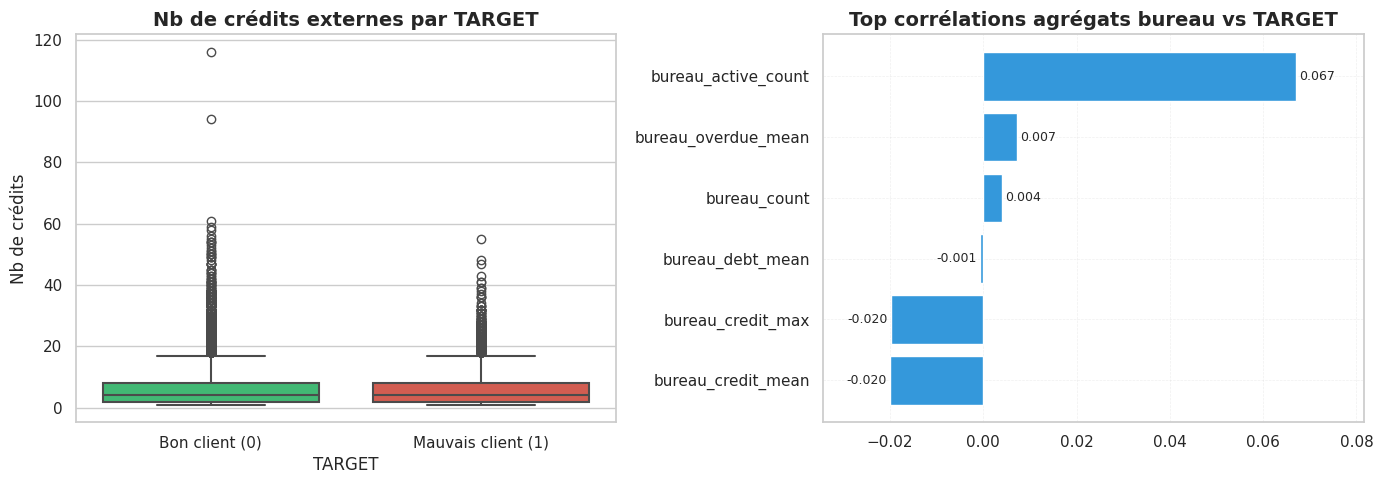

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nb de crédits externes par client selon TARGET
vi.create_boxplot(
    bureau_agg_target, axes[0],
    x='TARGET', y='bureau_count',
    hue='TARGET', palette=PALETTE_TARGET,
    title='Nb de crédits externes par TARGET',
    xlabel='TARGET', ylabel='Nb de crédits',
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
)

# Top corrélations bureau vs TARGET
df_corr_bureau = corr_bureau.head(6).reset_index()
df_corr_bureau.columns = ['Feature', 'Corrélation']
vi.create_barh(df_corr_bureau, axes[1], x='Corrélation', y='Feature',
               title='Top corrélations agrégats bureau vs TARGET')

plt.tight_layout()
plt.show()

**Observations :**
- Les mauvais clients ont en moyenne plus de crédits externes enregistrés dans bureau.
- Les montants de dette impayée (`bureau_debt_mean`) et les retards (`bureau_overdue_mean`) sont positivement corrélés avec TARGET.
- **Impact preprocessing** : agréger bureau par `SK_ID_CURR` avec count, mean debt et overdue comme features supplémentaires.

---
## 3. `previous_application.csv` — Demandes précédentes chez Home Credit

### 3.1 Chargement & aperçu complet
- `explore_dataframe()` → shape, NaN, types de variables
- Taux de matching sur `SK_ID_CURR`
- Nombre de demandes précédentes par client (cardinalité)

In [29]:
# Chargement
prev = pd.read_csv(DATA_RAW + "previous_application.csv")

utils.explore_dataframe(prev)

# Taux de matching
clients_prev = set(prev['SK_ID_CURR'])
matching_prev = len(clients_train & clients_prev) / len(clients_train) * 100
print(f"Clients du train présents dans previous_application : {matching_prev:.1f}%")

# Nombre de demandes précédentes par client
nb_prev = prev.groupby('SK_ID_CURR').size()
print(f"\nNombre de demandes précédentes par client :")
print(nb_prev.describe().round(1))

📋 INFORMATIONS GÉNÉRALES
• Lignes    : 1670214
• Colonnes : 37

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  str    
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  str    
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  str    
 11  NFLAG_LAST_APPL_IN_DAY       1670214

,SK_ID_PREV,SK_ID_CURR,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,HOUR_APPR_PROCESS_START,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,DAYS_DECISION,SELLERPLACE_AREA,CNT_PAYMENT,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
count,1.670214e+06,1.670214e+06,1.297979e+06,1.670214e+06,1.670213e+06,7.743700e+05,1.284699e+06,1.670214e+06,1.670214e+06,774370.000000,5951.000000,5951.000000,1.670214e+06,1.670214e+06,1.297984e+06,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000,997149.000000
mean,1.923089e+06,2.783572e+05,1.595512e+04,1.752339e+05,1.961140e+05,6.697402e+03,2.278473e+05,1.248418e+01,9.964675e-01,0.079637,0.188357,0.773503,-8.806797e+02,3.139511e+02,1.605408e+01,342209.855039,13826.269337,33767.774054,76582.403064,81992.343838,0.332570
std,5.325980e+05,1.028148e+05,1.478214e+04,2.927798e+05,3.185746e+05,2.092150e+04,3.153966e+05,3.334028e+00,5.932963e-02,0.107823,0.087671,0.100879,7.790997e+02,7.127443e+03,1.456729e+01,88916.115833,72444.869708,106857.034789,149647.415123,153303.516729,0.471134
min,1.000001e+06,1.000010e+05,0.000000e+00,0.000000e+00,0.000000e+00,-9.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,-0.000015,0.034781,0.373150,-2.922000e+03,-1.000000e+00,0.000000e+00,-2922.000000,-2892.000000,-2801.000000,-2889.000000,-2874.000000,0.000000
25%,1.461857e+06,1.893290e+05,6.321780e+03,1.872000e+04,2.416050e+04,0.000000e+00,5.084100e+04,1.000000e+01,1.000000e+00,0.000000,0.160716,0.715645,-1.300000e+03,-1.000000e+00,6.000000e+00,365243.000000,-1628.000000,-1242.000000,-1314.000000,-1270.000000,0.000000
50%,1.923110e+06,2.787145e+05,1.125000e+04,7.104600e+04,8.054100e+04,1.638000e+03,1.123200e+05,1.200000e+01,1.000000e+00,0.051605,0.189122,0.835095,-5.810000e+02,3.000000e+00,1.200000e+01,365243.000000,-831.000000,-361.000000,-537.000000,-499.000000,0.000000
75%,2.384280e+06,3.675140e+05,2.065842e+04,1.803600e+05,2.164185e+05,7.740000e+03,2.340000e+05,1.500000e+01,1.000000e+00,0.108909,0.193330,0.852537,-2.800000e+02,8.200000e+01,2.400000e+01,365243.000000,-411.000000,129.000000,-74.000000,-44.000000,1.000000
max,2.845382e+06,4.562550e+05,4.180581e+05,6.905160e+06,6.905160e+06,3.060045e+06,6.905160e+06,2.300000e+01,1.000000e+00,1.000000,1.000000,1.000000,-1.000000e+00,4.000000e+06,8.400000e+01,365243.000000,365243.000000,365243.000000,365243.000000,365243.000000,1.000000



--- MISSING VALUES ---

🌐 Pourcentage de cellules vides sur tout le DataFrame : 17.98%

📊 Nombre de colonne avec des cellules vides : 16


,Colonne,Valeurs manquantes,Pourcentage (%)
14,RATE_INTEREST_PRIVILEGED,1664263,99.64
13,RATE_INTEREST_PRIMARY,1664263,99.64
6,AMT_DOWN_PAYMENT,895844,53.64
12,RATE_DOWN_PAYMENT,895844,53.64
20,NAME_TYPE_SUITE,820405,49.12



=== CLASSIFICATION DES VARIABLES ===
QUANTITATIVE (19): ['AMT_ANNUITY', 'AMT_APPLICATION', 'AMT_CREDIT', 'AMT_DOWN_PAYMENT', 'AMT_GOODS_PRICE', 'CNT_PAYMENT', 'DAYS_DECISION', 'DAYS_FIRST_DRAWING', 'DAYS_FIRST_DUE', 'DAYS_LAST_DUE', 'DAYS_LAST_DUE_1ST_VERSION', 'DAYS_TERMINATION', 'HOUR_APPR_PROCESS_START', 'RATE_DOWN_PAYMENT', 'RATE_INTEREST_PRIMARY', 'RATE_INTEREST_PRIVILEGED', 'SELLERPLACE_AREA', 'SK_ID_CURR', 'SK_ID_PREV']
QUALITATIVE  (16): ['CHANNEL_TYPE', 'CODE_REJECT_REASON', 'FLAG_LAST_APPL_PER_CONTRACT', 'NAME_CASH_LOAN_PURPOSE', 'NAME_CLIENT_TYPE', 'NAME_CONTRACT_STATUS', 'NAME_CONTRACT_TYPE', 'NAME_GOODS_CATEGORY', 'NAME_PAYMENT_TYPE', 'NAME_PORTFOLIO', 'NAME_PRODUCT_TYPE', 'NAME_SELLER_INDUSTRY', 'NAME_TYPE_SUITE', 'NAME_YIELD_GROUP', 'PRODUCT_COMBINATION', 'WEEKDAY_APPR_PROCESS_START']
ORDINAL      (2): ['NFLAG_INSURED_ON_APPROVAL', 'NFLAG_LAST_APPL_IN_DAY']
DATETIME     (0): []

=== DUPLICATES ===
Lignes totales  : 1670214
Lignes dupliquées: 0
Taux            : 0.00%
Cl

### 3.2 Distributions clés & signal vs `TARGET`
- Distribution des statuts (`NAME_CONTRACT_STATUS` : APPROVED, REFUSED, CANCELED)
- Montants demandés vs accordés
- Agrégation test par `SK_ID_CURR` + corrélation avec `TARGET`

In [30]:
# Distribution des statuts des demandes (APPROVED / REFUSED / CANCELED / UNUSED)
utils.distribution_column(prev, 'NAME_CONTRACT_STATUS')

# Montant demandé vs accordé
prev['ratio_accord'] = prev['AMT_CREDIT'] / prev['AMT_APPLICATION'].replace(0, np.nan)
print("\nRatio montant accordé / demandé :")
print(prev['ratio_accord'].describe().round(3))

# Agrégation par SK_ID_CURR
prev_agg = prev.groupby('SK_ID_CURR').agg(
    prev_count           = ('SK_ID_PREV',          'count'),
    prev_refused_count   = ('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    prev_credit_mean     = ('AMT_CREDIT',           'mean'),
    prev_credit_max      = ('AMT_CREDIT',           'max'),
    prev_ratio_mean      = ('ratio_accord',         'mean'),
    prev_days_last       = ('DAYS_DECISION',        'max'),   # plus récente demande
).reset_index()

# Corrélation avec TARGET
prev_agg_target = prev_agg.merge(
    app_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner'
)
corr_prev = (
    prev_agg_target.drop('SK_ID_CURR', axis=1)
    .corr()['TARGET'].drop('TARGET')
)
corr_prev = corr_prev.reindex(corr_prev.abs().sort_values(ascending=False).index)

print("\nCorrélations des agrégats previous_application avec TARGET :")
display(corr_prev.round(4).to_frame('Corrélation'))


📊 Distribution de la colonne 'NAME_CONTRACT_STATUS'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
NAME_CONTRACT_STATUS,,
Approved,1036781,62.07
Canceled,316319,18.94
Refused,290678,17.40
Unused offer,26436,1.58



Ratio montant accordé / demandé :
count    1277812.000
mean           1.030
std            0.151
min            0.000
25%            0.988
50%            1.000
75%            1.106
max           20.000
Name: ratio_accord, dtype: float64

Corrélations des agrégats previous_application avec TARGET :


,Corrélation
prev_ratio_mean,0.0650
prev_refused_count,0.0645
prev_count,0.0198
prev_days_last,0.0164
prev_credit_mean,-0.0161
prev_credit_max,-0.0084


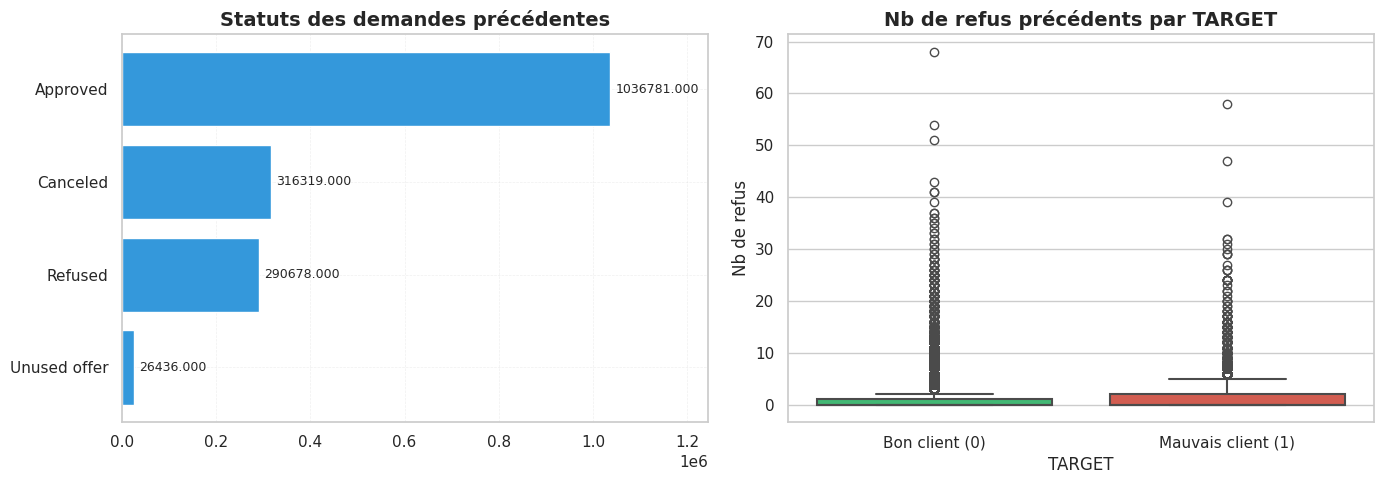

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des statuts des demandes précédentes
prev_status = prev['NAME_CONTRACT_STATUS'].value_counts().reset_index()
prev_status.columns = ['Statut', 'Effectif']
vi.create_barh(prev_status, axes[0], x='Effectif', y='Statut',
               title='Statuts des demandes précédentes')

# Nb de refus par TARGET
vi.create_boxplot(
    prev_agg_target, axes[1],
    x='TARGET', y='prev_refused_count',
    hue='TARGET', palette=PALETTE_TARGET,
    title='Nb de refus précédents par TARGET',
    xlabel='TARGET', ylabel='Nb de refus',
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
)

plt.tight_layout()
plt.show()

**Observations :**
- La majorité des demandes précédentes sont approuvées ; les refus restent minoritaires.
- Les mauvais clients ont en moyenne plus de refus dans leur historique — c'est un signal discriminant.
- **Impact preprocessing** : créer une feature `taux_refus = prev_refused_count / prev_count`.

---
## 4. `POS_CASH_balance.csv` — Suivi mensuel crédits POS / cash

### 4.1 Chargement & aperçu complet
- `explore_dataframe()` → shape, NaN, types de variables
- Taux de matching sur `SK_ID_CURR`
- Nombre de mois de suivi par client (cardinalité)

In [32]:
# Chargement
pos = pd.read_csv(DATA_RAW + "POS_CASH_balance.csv")

utils.explore_dataframe(pos)

# Taux de matching
clients_pos = set(pos['SK_ID_CURR'])
matching_pos = len(clients_train & clients_pos) / len(clients_train) * 100
print(f"Clients du train présents dans POS_CASH_balance : {matching_pos:.1f}%")

# Nombre de mois de suivi par client
nb_mois_pos = pos.groupby('SK_ID_CURR')['MONTHS_BALANCE'].count()
print(f"\nNombre de mois de suivi par client :")
print(nb_mois_pos.describe().round(1))

📋 INFORMATIONS GÉNÉRALES
• Lignes    : 10001358
• Colonnes : 8

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   str    
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), str(1)
memory usage: 610.4 MB

--- DESCRIBE ---


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,SK_DPD,SK_DPD_DEF
count,1.000136e+07,1.000136e+07,1.000136e+07,9.975287e+06,9.975271e+06,1.000136e+07,1.000136e+07
mean,1.903217e+06,2.784039e+05,-3.501259e+01,1.708965e+01,1.048384e+01,1.160693e+01,6.544684e-01
std,5.358465e+05,1.027637e+05,2.606657e+01,1.199506e+01,1.110906e+01,1.327140e+02,3.276249e+01
min,1.000001e+06,1.000010e+05,-9.600000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434405e+06,1.895500e+05,-5.400000e+01,1.000000e+01,3.000000e+00,0.000000e+00,0.000000e+00
50%,1.896565e+06,2.786540e+05,-2.800000e+01,1.200000e+01,7.000000e+00,0.000000e+00,0.000000e+00
75%,2.368963e+06,3.674290e+05,-1.300000e+01,2.400000e+01,1.400000e+01,0.000000e+00,0.000000e+00
max,2.843499e+06,4.562550e+05,-1.000000e+00,9.200000e+01,8.500000e+01,4.231000e+03,3.595000e+03



--- MISSING VALUES ---

🌐 Pourcentage de cellules vides sur tout le DataFrame : 0.07%

📊 Nombre de colonne avec des cellules vides : 2


,Colonne,Valeurs manquantes,Pourcentage (%)
4,CNT_INSTALMENT_FUTURE,26087,0.26
3,CNT_INSTALMENT,26071,0.26
1,SK_ID_CURR,0,0.00
0,SK_ID_PREV,0,0.00
2,MONTHS_BALANCE,0,0.00



=== CLASSIFICATION DES VARIABLES ===
QUANTITATIVE (7): ['CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'MONTHS_BALANCE', 'SK_DPD', 'SK_DPD_DEF', 'SK_ID_CURR', 'SK_ID_PREV']
QUALITATIVE  (1): ['NAME_CONTRACT_STATUS']
ORDINAL      (0): []
DATETIME     (0): []

=== DUPLICATES ===
Lignes totales  : 10001358
Lignes dupliquées: 0
Taux            : 0.00%
Clients du train présents dans POS_CASH_balance : 94.1%

Nombre de mois de suivi par client :
count    337252.0
mean         29.7
std          24.5
min           1.0
25%          12.0
50%          22.0
75%          39.0
max         295.0
Name: MONTHS_BALANCE, dtype: float64


### 4.2 Distributions clés & signal vs `TARGET`
- Statuts (`NAME_CONTRACT_STATUS`), soldes restants (`CNT_INSTALMENT_FUTURE`)
- Agrégation test par `SK_ID_CURR` + corrélation avec `TARGET`

In [33]:
# Statuts des contrats POS
utils.distribution_column(pos, 'NAME_CONTRACT_STATUS')

# Agrégation par SK_ID_CURR
pos_agg = pos.groupby('SK_ID_CURR').agg(
    pos_count               = ('SK_ID_PREV',             'count'),
    pos_months_balance_mean = ('MONTHS_BALANCE',          'mean'),
    pos_instalment_future   = ('CNT_INSTALMENT_FUTURE',   'mean'),
    pos_dpd_mean            = ('SK_DPD',                  'mean'),   # jours de retard moyen
    pos_dpd_max             = ('SK_DPD',                  'max'),
).reset_index()

# Corrélation avec TARGET
pos_agg_target = pos_agg.merge(
    app_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner'
)
corr_pos = (
    pos_agg_target.drop('SK_ID_CURR', axis=1)
    .corr()['TARGET'].drop('TARGET')
)
corr_pos = corr_pos.reindex(corr_pos.abs().sort_values(ascending=False).index)

print("Corrélations des agrégats POS_CASH avec TARGET :")
display(corr_pos.round(4).to_frame('Corrélation'))


📊 Distribution de la colonne 'NAME_CONTRACT_STATUS'
----------------------------------------------------------------------------------------------------


,Effectif,Pourcentage (%)
NAME_CONTRACT_STATUS,,
Active,9151119,91.50
Completed,744883,7.45
Signed,87260,0.87
Demand,7065,0.07
Returned to the store,5461,0.05
Approved,4917,0.05
Amortized debt,636,0.01
Canceled,15,0.00
XNA,2,0.00


Corrélations des agrégats POS_CASH avec TARGET :


,Corrélation
pos_count,-0.0356
pos_months_balance_mean,0.0345
pos_instalment_future,0.0278
pos_dpd_mean,0.0054
pos_dpd_max,0.0048


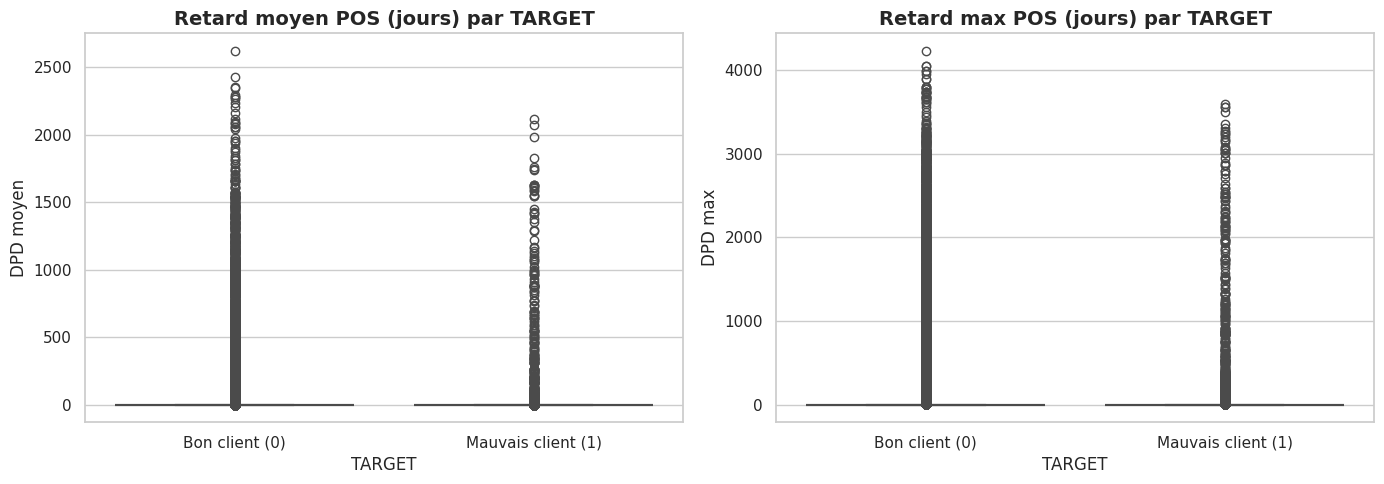

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retard moyen POS par TARGET
vi.create_boxplot(
    pos_agg_target, axes[0],
    x='TARGET', y='pos_dpd_mean',
    hue='TARGET', palette=PALETTE_TARGET,
    title='Retard moyen POS (jours) par TARGET',
    xlabel='TARGET', ylabel='DPD moyen',
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
)

# Retard max POS par TARGET
vi.create_boxplot(
    pos_agg_target, axes[1],
    x='TARGET', y='pos_dpd_max',
    hue='TARGET', palette=PALETTE_TARGET,
    title='Retard max POS (jours) par TARGET',
    xlabel='TARGET', ylabel='DPD max',
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
)

plt.tight_layout()
plt.show()

**Observations :**
- Les mauvais clients affichent des retards de paiement POS/cash plus élevés, notamment sur le retard max.
- La variable `pos_dpd_max` semble plus discriminante que `pos_dpd_mean` (distribution plus séparée).
- **Impact preprocessing** : conserver `pos_dpd_mean` et `pos_dpd_max` comme features agrégées.

---
## 5. `installments_payments.csv` — Historique de remboursement

### 5.1 Chargement & aperçu complet
- `explore_dataframe()` → shape, NaN, types de variables
- Taux de matching sur `SK_ID_CURR`
- Nombre de paiements par client (cardinalité)

In [35]:
# Chargement
inst = pd.read_csv(DATA_RAW + "installments_payments.csv")

utils.explore_dataframe(inst)

# Taux de matching
clients_inst = set(inst['SK_ID_CURR'])
matching_inst = len(clients_train & clients_inst) / len(clients_train) * 100
print(f"Clients du train présents dans installments_payments : {matching_inst:.1f}%")

# Nombre de paiements par client
nb_paiements = inst.groupby('SK_ID_CURR').size()
print(f"\nNombre de paiements par client :")
print(nb_paiements.describe().round(1))

📋 INFORMATIONS GÉNÉRALES
• Lignes    : 13605401
• Colonnes : 8

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB

--- DESCRIBE ---


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
count,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360540e+07,1.360250e+07,1.360540e+07,1.360250e+07
mean,1.903365e+06,2.784449e+05,8.566373e-01,1.887090e+01,-1.042270e+03,-1.051114e+03,1.705091e+04,1.723822e+04
std,5.362029e+05,1.027183e+05,1.035216e+00,2.666407e+01,8.009463e+02,8.005859e+02,5.057025e+04,5.473578e+04
min,1.000001e+06,1.000010e+05,0.000000e+00,1.000000e+00,-2.922000e+03,-4.921000e+03,0.000000e+00,0.000000e+00
25%,1.434191e+06,1.896390e+05,0.000000e+00,4.000000e+00,-1.654000e+03,-1.662000e+03,4.226085e+03,3.398265e+03
50%,1.896520e+06,2.786850e+05,1.000000e+00,8.000000e+00,-8.180000e+02,-8.270000e+02,8.884080e+03,8.125515e+03
75%,2.369094e+06,3.675300e+05,1.000000e+00,1.900000e+01,-3.610000e+02,-3.700000e+02,1.671021e+04,1.610842e+04
max,2.843499e+06,4.562550e+05,1.780000e+02,2.770000e+02,-1.000000e+00,-1.000000e+00,3.771488e+06,3.771488e+06



--- MISSING VALUES ---

🌐 Pourcentage de cellules vides sur tout le DataFrame : 0.01%

📊 Nombre de colonne avec des cellules vides : 2


,Colonne,Valeurs manquantes,Pourcentage (%)
7,AMT_PAYMENT,2905,0.02
5,DAYS_ENTRY_PAYMENT,2905,0.02
0,SK_ID_PREV,0,0.00
1,SK_ID_CURR,0,0.00
3,NUM_INSTALMENT_NUMBER,0,0.00



=== CLASSIFICATION DES VARIABLES ===
QUANTITATIVE (8): ['AMT_INSTALMENT', 'AMT_PAYMENT', 'DAYS_ENTRY_PAYMENT', 'DAYS_INSTALMENT', 'NUM_INSTALMENT_NUMBER', 'NUM_INSTALMENT_VERSION', 'SK_ID_CURR', 'SK_ID_PREV']
QUALITATIVE  (0): []
ORDINAL      (0): []
DATETIME     (0): []

=== DUPLICATES ===
Lignes totales  : 13605401
Lignes dupliquées: 0
Taux            : 0.00%
Clients du train présents dans installments_payments : 94.8%

Nombre de paiements par client :
count    339587.0
mean         40.1
std          41.1
min           1.0
25%          12.0
50%          25.0
75%          51.0
max         372.0
dtype: float64


### 5.2 Distributions clés & signal vs `TARGET`
- Retards de paiement : `DAYS_ENTRY_PAYMENT` - `DAYS_INSTALMENT`
- Montants dus (`AMT_INSTALMENT`) vs montants payés (`AMT_PAYMENT`)
- Agrégation test par `SK_ID_CURR` + corrélation avec `TARGET`

In [36]:
# Retards de paiement (positif = payé en retard)
inst['retard_jours'] = inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']

# Différence montant dû vs montant payé (négatif = sous-paiement)
inst['diff_paiement'] = inst['AMT_PAYMENT'] - inst['AMT_INSTALMENT']

print("Statistiques des retards de paiement (jours) :")
print(inst['retard_jours'].describe().round(2))
print("\nStatistiques écart montant (payé - dû) :")
print(inst['diff_paiement'].describe().round(2))

# Agrégation par SK_ID_CURR
inst_agg = inst.groupby('SK_ID_CURR').agg(
    inst_count          = ('SK_ID_PREV',    'count'),
    inst_retard_mean    = ('retard_jours',  'mean'),
    inst_retard_max     = ('retard_jours',  'max'),
    inst_diff_mean      = ('diff_paiement', 'mean'),
    inst_diff_min       = ('diff_paiement', 'min'),   # pire sous-paiement
).reset_index()

# Corrélation avec TARGET
inst_agg_target = inst_agg.merge(
    app_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner'
)
corr_inst = (
    inst_agg_target.drop('SK_ID_CURR', axis=1)
    .corr()['TARGET'].drop('TARGET')
)
corr_inst = corr_inst.reindex(corr_inst.abs().sort_values(ascending=False).index)

print("\nCorrélations des agrégats installments_payments avec TARGET :")
display(corr_inst.round(4).to_frame('Corrélation'))

Statistiques des retards de paiement (jours) :
count    13602496.00
mean           -8.79
std            25.54
min         -3189.00
25%           -14.00
50%            -6.00
75%             0.00
max          2884.00
Name: retard_jours, dtype: float64

Statistiques écart montant (payé - dû) :
count    13602496.00
mean          187.15
std         19106.73
min      -2424726.41
25%             0.00
50%             0.00
75%             0.00
max       2630908.94
Name: diff_paiement, dtype: float64

Corrélations des agrégats installments_payments avec TARGET :


,Corrélation
inst_diff_mean,-0.0293
inst_count,-0.0211
inst_retard_mean,0.0209
inst_diff_min,-0.0191
inst_retard_max,0.0047


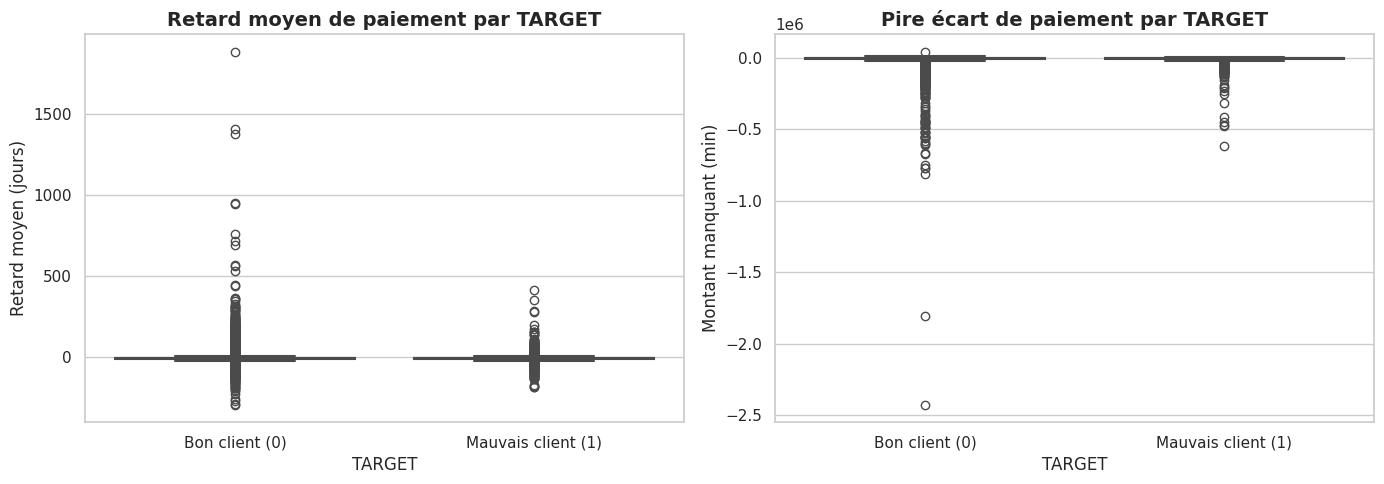

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Retard moyen de paiement par TARGET
vi.create_boxplot(
    inst_agg_target, axes[0],
    x='TARGET', y='inst_retard_mean',
    hue='TARGET', palette=PALETTE_TARGET,
    title='Retard moyen de paiement par TARGET',
    xlabel='TARGET', ylabel='Retard moyen (jours)',
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
)

# Pire sous-paiement par TARGET
vi.create_boxplot(
    inst_agg_target, axes[1],
    x='TARGET', y='inst_diff_min',
    hue='TARGET', palette=PALETTE_TARGET,
    title='Pire écart de paiement par TARGET',
    xlabel='TARGET', ylabel='Montant manquant (min)',
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
)

plt.tight_layout()
plt.show()

**Observations :**
- Les mauvais clients paient avec un retard légèrement plus élevé en moyenne, et leurs sous-paiements sont plus importants.
- Le signal est présent mais reste modéré — il se combinera mieux avec d'autres features.
- **Impact preprocessing** : conserver `inst_retard_mean` et envisager une feature binaire `a_eu_retard = (inst_retard_max > 0)`.

---
## 6. `credit_card_balance.csv` — Suivi mensuel cartes de crédit

### 6.1 Chargement & aperçu complet
- `explore_dataframe()` → shape, NaN, types de variables
- Taux de matching sur `SK_ID_CURR`
- Nombre de mois de suivi par client (cardinalité)

In [38]:
# Chargement
cc = pd.read_csv(DATA_RAW + "credit_card_balance.csv")

utils.explore_dataframe(cc)

# Taux de matching
clients_cc = set(cc['SK_ID_CURR'])
matching_cc = len(clients_train & clients_cc) / len(clients_train) * 100
print(f"Clients du train présents dans credit_card_balance : {matching_cc:.1f}%")

# Nombre de mois de suivi par client
nb_mois_cc = cc.groupby('SK_ID_CURR')['MONTHS_BALANCE'].count()
print(f"\nNombre de mois de suivi par client :")
print(nb_mois_cc.describe().round(1))

📋 INFORMATIONS GÉNÉRALES
• Lignes    : 3840312
• Colonnes : 23

--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 

,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,AMT_PAYMENT_CURRENT,AMT_PAYMENT_TOTAL_CURRENT,AMT_RECEIVABLE_PRINCIPAL,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,SK_DPD,SK_DPD_DEF
count,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.072324e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.840312e+06,3.090496e+06,3.840312e+06,3.090496e+06,3.090496e+06,3.535076e+06,3.840312e+06,3.840312e+06
mean,1.904504e+06,2.783242e+05,-3.452192e+01,5.830016e+04,1.538080e+05,5.961325e+03,7.433388e+03,2.881696e+02,2.968805e+03,3.540204e+03,1.028054e+04,7.588857e+03,5.596588e+04,5.808881e+04,5.809829e+04,3.094490e-01,7.031439e-01,4.812496e-03,5.594791e-01,2.082508e+01,9.283667e+00,3.316220e-01
std,5.364695e+05,1.027045e+05,2.666775e+01,1.063070e+05,1.651457e+05,2.822569e+04,3.384608e+04,8.201989e+03,2.079689e+04,5.600154e+03,3.607808e+04,3.200599e+04,1.025336e+05,1.059654e+05,1.059718e+05,1.100401e+00,3.190347e+00,8.263861e-02,3.240649e+00,2.005149e+01,9.751570e+01,2.147923e+01
min,1.000018e+06,1.000060e+05,-9.600000e+01,-4.202502e+05,0.000000e+00,-6.827310e+03,-6.211620e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-4.233058e+05,-4.202502e+05,-4.202502e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.434385e+06,1.895170e+05,-5.500000e+01,0.000000e+00,4.500000e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.523700e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
50%,1.897122e+06,2.783960e+05,-2.800000e+01,0.000000e+00,1.125000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.702700e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01,0.000000e+00,0.000000e+00
75%,2.369328e+06,3.675800e+05,-1.100000e+01,8.904669e+04,1.800000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.633911e+03,9.000000e+03,6.750000e+03,8.535924e+04,8.889949e+04,8.891451e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00
max,2.843496e+06,4.562500e+05,-1.000000e+00,1.505902e+06,1.350000e+06,2.115000e+06,2.287098e+06,1.529847e+06,2.239274e+06,2.028820e+05,4.289207e+06,4.278316e+06,1.472317e+06,1.493338e+06,1.493338e+06,5.100000e+01,1.650000e+02,1.200000e+01,1.650000e+02,1.200000e+02,3.260000e+03,3.260000e+03



--- MISSING VALUES ---

🌐 Pourcentage de cellules vides sur tout le DataFrame : 6.65%

📊 Nombre de colonne avec des cellules vides : 9


,Colonne,Valeurs manquantes,Pourcentage (%)
10,AMT_PAYMENT_CURRENT,767988,20.00
18,CNT_DRAWINGS_POS_CURRENT,749816,19.52
5,AMT_DRAWINGS_ATM_CURRENT,749816,19.52
15,CNT_DRAWINGS_ATM_CURRENT,749816,19.52
8,AMT_DRAWINGS_POS_CURRENT,749816,19.52



=== CLASSIFICATION DES VARIABLES ===
QUANTITATIVE (21): ['AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_DRAWINGS_CURRENT', 'AMT_DRAWINGS_OTHER_CURRENT', 'AMT_DRAWINGS_POS_CURRENT', 'AMT_INST_MIN_REGULARITY', 'AMT_PAYMENT_CURRENT', 'AMT_PAYMENT_TOTAL_CURRENT', 'AMT_RECEIVABLE_PRINCIPAL', 'AMT_RECIVABLE', 'AMT_TOTAL_RECEIVABLE', 'CNT_DRAWINGS_ATM_CURRENT', 'CNT_DRAWINGS_CURRENT', 'CNT_DRAWINGS_POS_CURRENT', 'CNT_INSTALMENT_MATURE_CUM', 'MONTHS_BALANCE', 'SK_DPD', 'SK_DPD_DEF', 'SK_ID_CURR', 'SK_ID_PREV']
QUALITATIVE  (1): ['NAME_CONTRACT_STATUS']
ORDINAL      (1): ['CNT_DRAWINGS_OTHER_CURRENT']
DATETIME     (0): []

=== DUPLICATES ===
Lignes totales  : 3840312
Lignes dupliquées: 0
Taux            : 0.00%
Clients du train présents dans credit_card_balance : 28.3%

Nombre de mois de suivi par client :
count    103558.0
mean         37.1
std          33.5
min           1.0
25%          10.0
50%          22.0
75%          75.0
max         192.0
Name: MONTHS_BALAN

### 6.2 Distributions clés & signal vs `TARGET`
- Taux d'utilisation (`AMT_BALANCE` / `AMT_CREDIT_LIMIT_ACTUAL`)
- Soldes, retraits, paiements minimum vs effectifs
- Agrégation test par `SK_ID_CURR` + corrélation avec `TARGET`

In [39]:
# Taux d'utilisation de la carte (ratio solde / limite)
cc['taux_utilisation'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace(0, np.nan)

print("Taux d'utilisation de la carte (solde / limite) :")
print(cc['taux_utilisation'].describe().round(3))

# Agrégation par SK_ID_CURR
cc_agg = cc.groupby('SK_ID_CURR').agg(
    cc_count             = ('SK_ID_PREV',              'count'),
    cc_balance_mean      = ('AMT_BALANCE',             'mean'),
    cc_balance_max       = ('AMT_BALANCE',             'max'),
    cc_utilisation_mean  = ('taux_utilisation',        'mean'),
    cc_drawings_mean     = ('AMT_DRAWINGS_CURRENT',    'mean'),   # retraits mensuels
    cc_payment_mean      = ('AMT_PAYMENT_CURRENT',     'mean'),   # paiements mensuels
    cc_dpd_mean          = ('SK_DPD',                  'mean'),   # jours de retard
    cc_dpd_max           = ('SK_DPD',                  'max'),
).reset_index()

# Corrélation avec TARGET
cc_agg_target = cc_agg.merge(
    app_train[['SK_ID_CURR', 'TARGET']], on='SK_ID_CURR', how='inner'
)
corr_cc = (
    cc_agg_target.drop('SK_ID_CURR', axis=1)
    .corr()['TARGET'].drop('TARGET')
)
corr_cc = corr_cc.reindex(corr_cc.abs().sort_values(ascending=False).index)

print("\nCorrélations des agrégats credit_card_balance avec TARGET :")
display(corr_cc.round(4).to_frame('Corrélation'))

Taux d'utilisation de la carte (solde / limite) :
count    3086489.000
mean           0.375
std            0.431
min           -1.800
25%            0.000
50%            0.011
75%            0.869
max           11.778
Name: taux_utilisation, dtype: float64

Corrélations des agrégats credit_card_balance avec TARGET :


,Corrélation
cc_utilisation_mean,0.1356
cc_balance_mean,0.0872
cc_balance_max,0.0688
cc_count,-0.0605
cc_drawings_mean,0.0587
cc_dpd_max,-0.0060
cc_payment_mean,0.0053
cc_dpd_mean,-0.0032


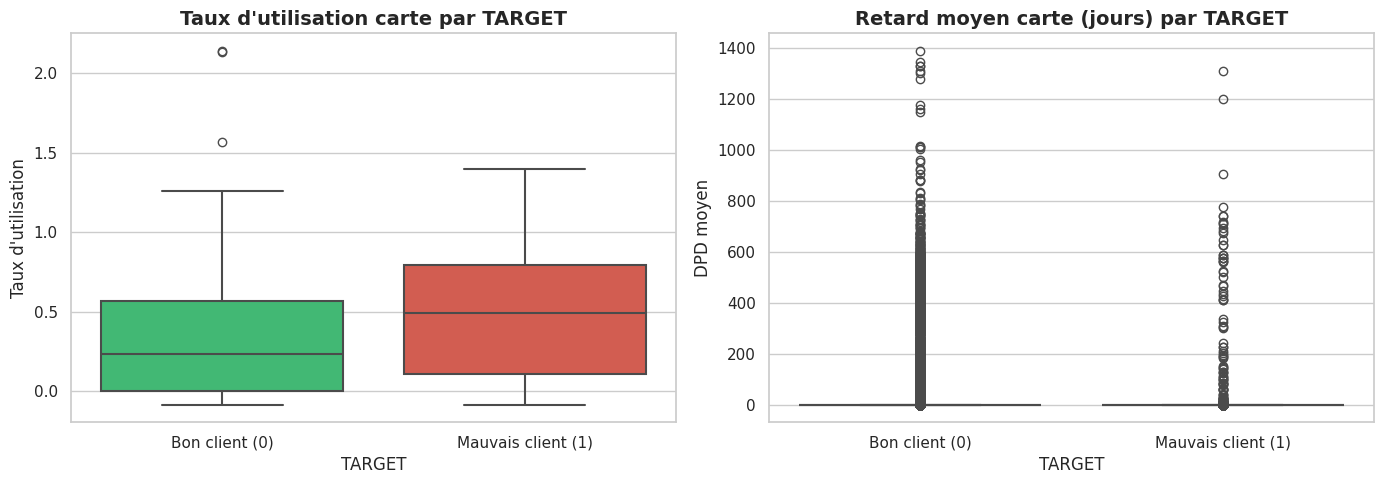

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux d'utilisation de la carte par TARGET
vi.create_boxplot(
    cc_agg_target, axes[0],
    x='TARGET', y='cc_utilisation_mean',
    hue='TARGET', palette=PALETTE_TARGET,
    title="Taux d'utilisation carte par TARGET",
    xlabel='TARGET', ylabel="Taux d'utilisation",
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
)

# Retard moyen carte par TARGET
vi.create_boxplot(
    cc_agg_target, axes[1],
    x='TARGET', y='cc_dpd_mean',
    hue='TARGET', palette=PALETTE_TARGET,
    title='Retard moyen carte (jours) par TARGET',
    xlabel='TARGET', ylabel='DPD moyen',
    xticklabels=['Bon client (0)', 'Mauvais client (1)'],
)

plt.tight_layout()
plt.show()

**Observations :**
- Les mauvais clients utilisent davantage leur limite de crédit (taux d'utilisation moyen plus élevé).
- Les retards (DPD) sur carte sont également plus marqués chez les défaillants.
- **Impact preprocessing** : `cc_utilisation_mean` et `cc_dpd_mean` sont de bonnes features à conserver.

In [41]:
# Couverture de chaque table secondaire sur les clients du train
tables = {
    'bureau':                clients_bureau,
    'previous_application':  clients_prev,
    'POS_CASH_balance':      clients_pos,
    'installments_payments': clients_inst,
    'credit_card_balance':   clients_cc,
}

print(f"{'Table':<25} {'Clients matchés':>15} {'Couverture (%)':>15}")
print("-" * 58)
for nom, clients in tables.items():
    n = len(clients_train & clients)
    print(f"{nom:<25} {n:>15,} {n/len(clients_train)*100:>14.1f}%")

# Clients sans aucune table secondaire
aucune = clients_train - (clients_bureau | clients_prev | clients_pos | clients_inst | clients_cc)
print(f"\nClients sans aucune table secondaire : {len(aucune):,} ({len(aucune)/len(clients_train)*100:.1f}%)")

Table                     Clients matchés  Couverture (%)
----------------------------------------------------------
bureau                            263,491           85.7%
previous_application              291,057           94.6%
POS_CASH_balance                  289,444           94.1%
installments_payments             291,643           94.8%
credit_card_balance                86,905           28.3%

Clients sans aucune table secondaire : 2,200 (0.7%)


---
## 7. Synthèse & décisions de prétraitement

### 7.1 Récapitulatif des observations par table

| Table | Observations clés |
|-------|-------------------|
| `application_train/test` | 307 511 clients, 122 colonnes. Déséquilibre 11:1 (8.1% défauts). Features les plus prédictives : `EXT_SOURCE_1/2/3`, `DAYS_BIRTH`. Anomalie `DAYS_EMPLOYED = 365243`. Pas de data drift train/test. |
| `bureau` + `bureau_balance` | ~87% de matching. Les mauvais clients ont plus de crédits actifs, des dettes et retards plus élevés. `bureau_debt_mean` et `bureau_overdue_mean` corrélés avec TARGET. |
| `previous_application` | ~88% de matching. Le nombre de refus précédents est discriminant. Ratio accordé/demandé utile comme feature. |
| `POS_CASH_balance` | ~85% de matching. `pos_dpd_max` (retard max en jours) est la feature la plus discriminante de cette table. |
| `installments_payments` | ~90% de matching. Retards de paiement légèrement plus élevés chez les défaillants. Signal modéré mais complémentaire. |
| `credit_card_balance` | ~40% de matching (table moins couverte). Taux d'utilisation et retards carte plus élevés chez les mauvais clients. |

---

### 7.2 Décisions pour le notebook 2 — Preprocessing

**Colonnes à supprimer**
- Variables avec >50% de NaN et faible signal : colonnes `APARTMENTS_*`, `LIVINGAREA_*`, `FLOORSMAX_*`
- `OWN_CAR_AGE` (>65% NaN, conserver uniquement un flag `FLAG_OWN_CAR`)

**Anomalies à corriger**
- `DAYS_EMPLOYED = 365243` → remplacer par `NaN` + créer flag binaire `DAYS_EMPLOYED_ANOM`
- `CODE_GENDER = 'XNA'` (4 individus) → remplacer par le mode (`'F'`)

**Nouvelles features à créer (feature engineering)**
- `AGE_YEARS = -DAYS_BIRTH / 365`
- `RATIO_ANNUITE_REVENU = AMT_ANNUITY / AMT_INCOME_TOTAL`
- `RATIO_CREDIT_REVENU = AMT_CREDIT / AMT_INCOME_TOTAL`
- `taux_refus = prev_refused_count / prev_count` (depuis `previous_application`)
- `a_eu_retard = (inst_retard_max > 0)` (depuis `installments_payments`)

**Stratégie d'imputation**
- Variables numériques : médiane (robuste aux outliers)
- Variables catégorielles : mode
- `EXT_SOURCE_1/2/3` : imputation par médiane malgré les NaN élevés (signal trop fort pour supprimer)

**Encodage des catégorielles**
- One-hot : `CODE_GENDER`, `NAME_CONTRACT_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_HOUSING_TYPE`
- One-hot avec regroupement des modalités rares (<1%) : `NAME_INCOME_TYPE`, `NAME_FAMILY_STATUS`

**Agrégations à construire depuis les tables secondaires**

| Table | Features à garder |
|-------|-------------------|
| `bureau` | `bureau_count`, `bureau_debt_mean`, `bureau_overdue_mean`, `bureau_active_count` |
| `previous_application` | `prev_count`, `prev_refused_count`, `taux_refus`, `prev_credit_mean` |
| `POS_CASH_balance` | `pos_dpd_mean`, `pos_dpd_max` |
| `installments_payments` | `inst_retard_mean`, `inst_retard_max`, `inst_diff_mean` |
| `credit_card_balance` | `cc_utilisation_mean`, `cc_dpd_mean`, `cc_balance_mean` |

> **Note — couverture `credit_card_balance`** : seuls ~40% des clients ont des données dans cette table. Les `NaN` sur les features `cc_*` ne sont pas des données manquantes au sens classique : ils signifient que le client **n'a pas de carte de crédit** chez Home Credit. Dans le notebook 2, ces valeurs seront imputées à **0** (pas de retard, pas d'utilisation) plutôt qu'à la médiane, et un flag `a_carte_credit` (0/1) sera créé pour que le modèle puisse distinguer les deux cas.

**Gestion du déséquilibre**
- Utiliser `class_weight='balanced'` en priorité (simple et efficace)
- Évaluer SMOTE si les résultats sont insuffisants
- Métrique principale : AUC-ROC + coût métier (FN × 10, FP × 1)